In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
"""
Initialize the analysis environment by loading essential modules and setting up
the Python path to access custom analysis functions.
"""

# Enable automatic reloading of modules for interactive development
%load_ext autoreload
%autoreload 2

# Import essential system modules
import sys
from pathlib import Path

# Define the path to custom analysis modules
# Note: Update this path to match your local installation
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

# Add module path to system path for importing custom functions
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")
print("🔄 Auto-reload enabled for interactive development")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis
🔄 Auto-reload enabled for interactive development


In [2]:
# ALM recordings — sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13"
]


In [3]:
# =============================================================================
# Build CD zarrs for the listed sessions
# =============================================================================
from pathlib import Path

from ephys_dimension_reduction_CD_pipeline import build_cd_dataset

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

# CD configuration
align                  = "go_cue"
binsize                = "0.1"
brain_regions_groups   = [[]]                    # [[]] => all units (RG_ALL)
time_windows           = [(-1, 0)]           # CD-fitting window(s)
#trial_types            = ("right_choice_trials", "left_choice_trials")
trial_types            = ("switch_LR_trials", "switch_RL_trials")
min_units_num          = 30
projection_time_window = None                    # None => full PSTH time axis
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True
zscore_units           = True

failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,                               # None => no region filtering
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    trial_types=trial_types,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
    #zscore_units=zscore_units,
)



Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr

Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr

Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (-1, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr

Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45
  Region R

In [12]:
failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root, behavior_root=behavior_root, cd_root=cd_root,
    metadata=None,
    binsize="0.1",
    align="trial_start",
    brain_regions_groups=[[]],
    time_windows=[(0, 0)],           # unused for axis fit, kept for naming
    trial_types=("right_choice_trials", "left_choice_trials"),
    projection_time_window=None,
    two_fold_cv=True, norm_mode="divide_sqrtN", random_state=0, overwrite=True,
    # ---- common-action axis ----
    axis_mode="common_action",
    early_time_window=(0.0, 1.0),
    late_time_window=(3.0, 4.0),
    restrict_events=("trial_start", "go_cue"),
    restrict_align="trial_start",
)


Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
  restrict_events=('trial_start', 'go_cue') (align=trial_start): 285/539 trials cover [0.0, 4.0]
  Region RG_ALL (ALL): ALL units
    ✔ Finished time window (0, 0): /root/capsule/scratch/CD_results/CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr

Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
  restrict_events=('trial_start', 'go_cue') (align=trial_start): 276/518 trials cover [0.0, 4.0]
  Region RG_ALL

Viewing common-action axis: RG_ALL (ALL), align=trial_start, early=(0.0, 1.0), late=(3.0, 4.0)

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr


Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


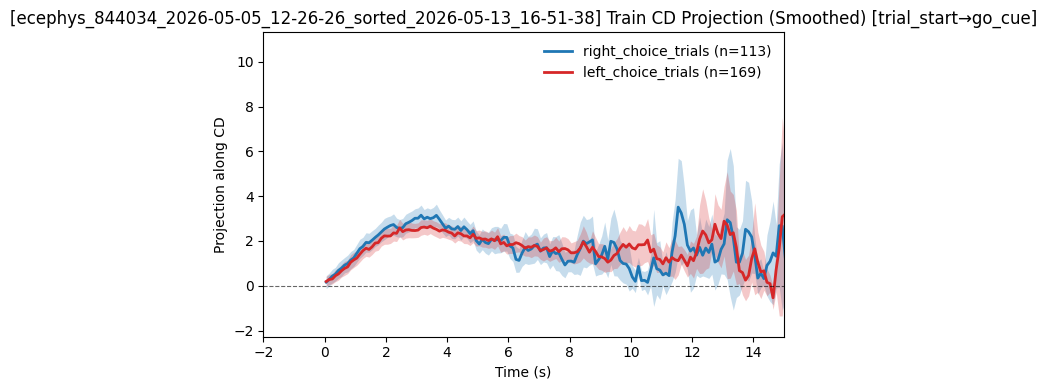

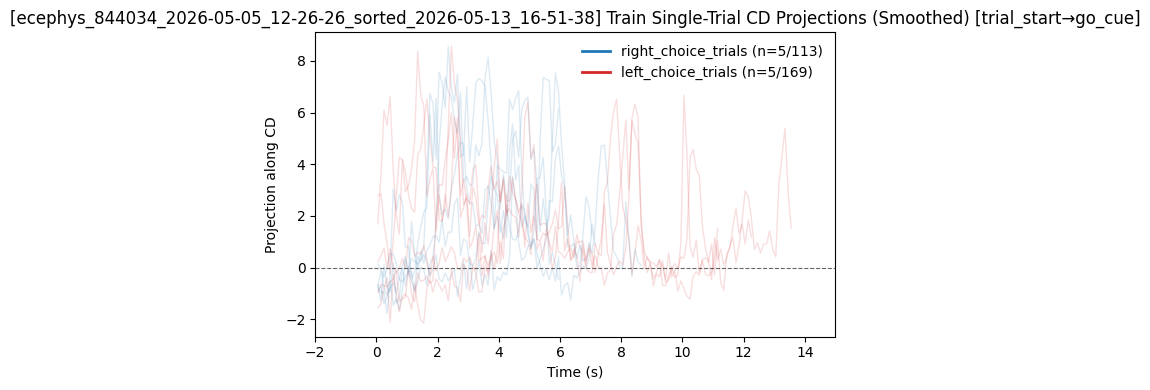

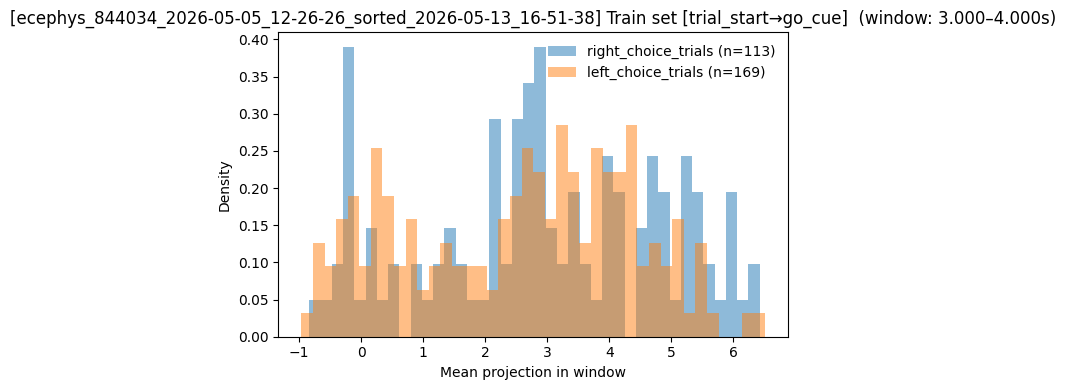


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


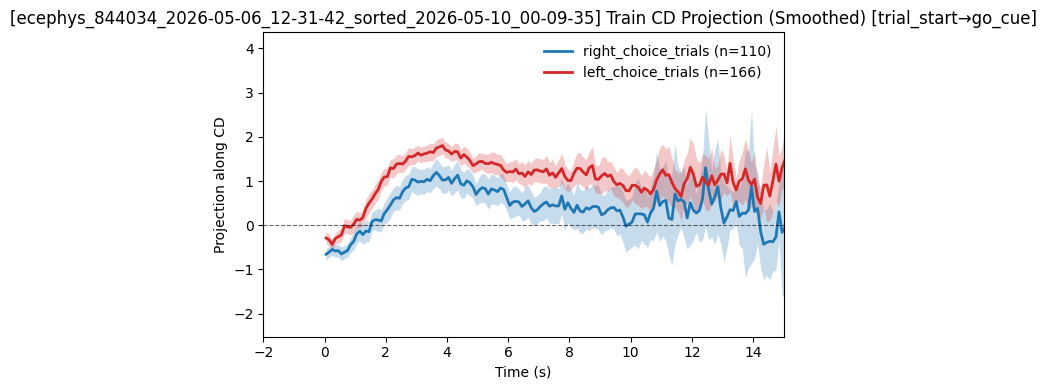

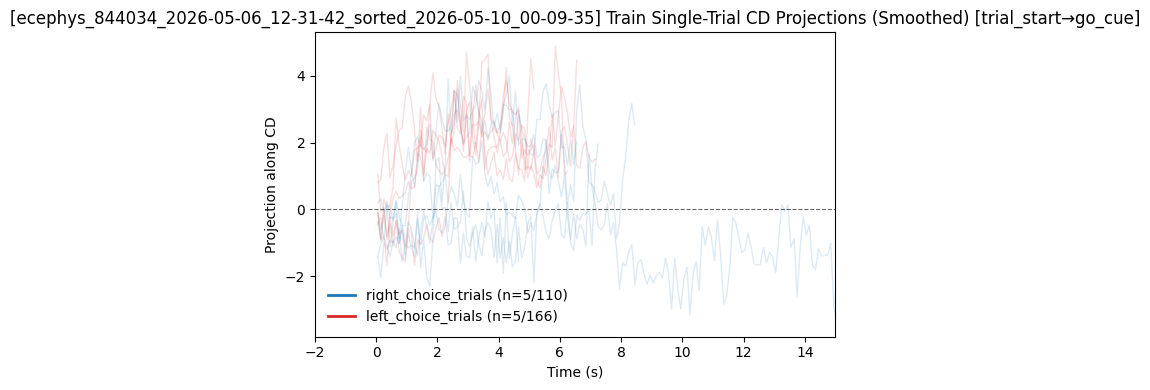

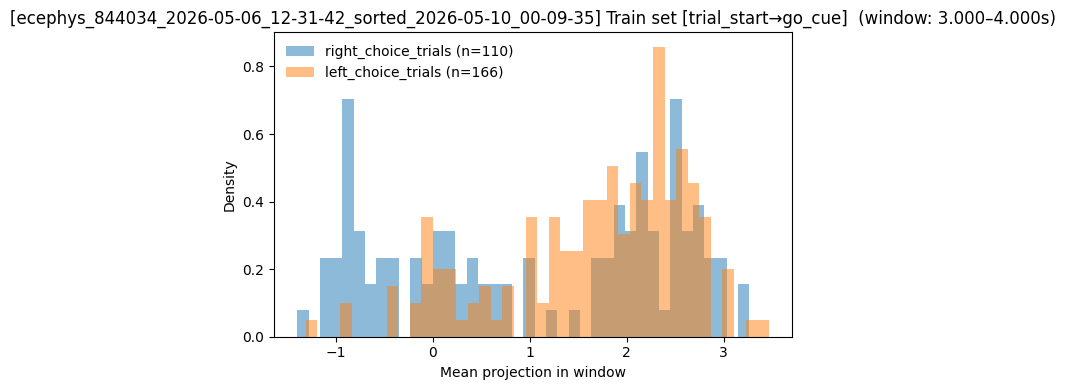


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


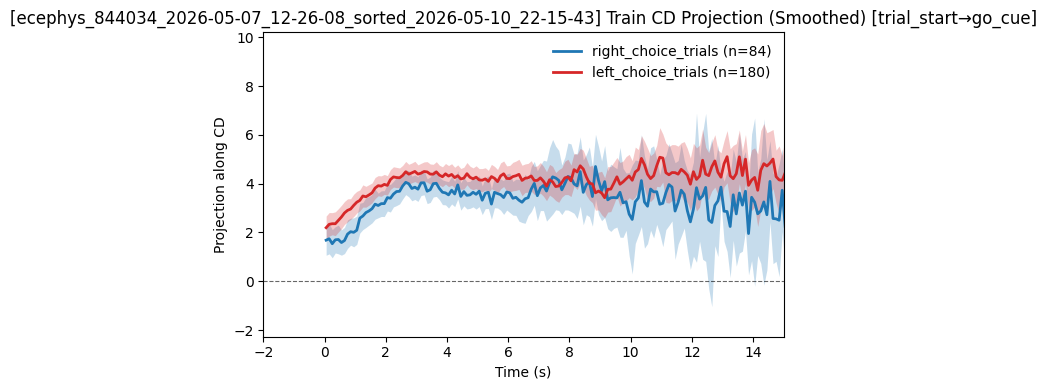

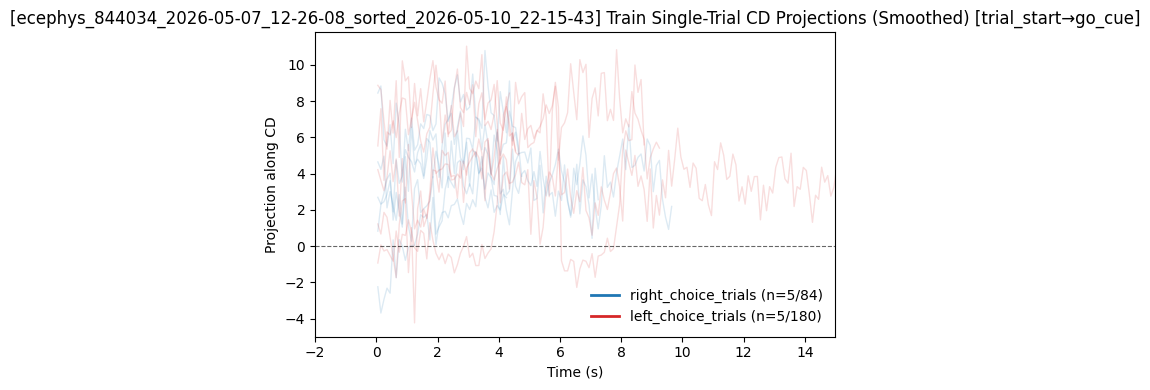

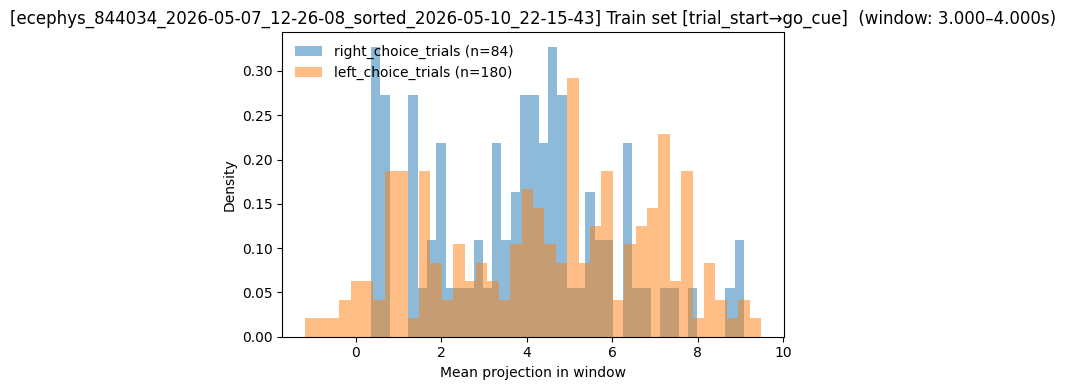


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


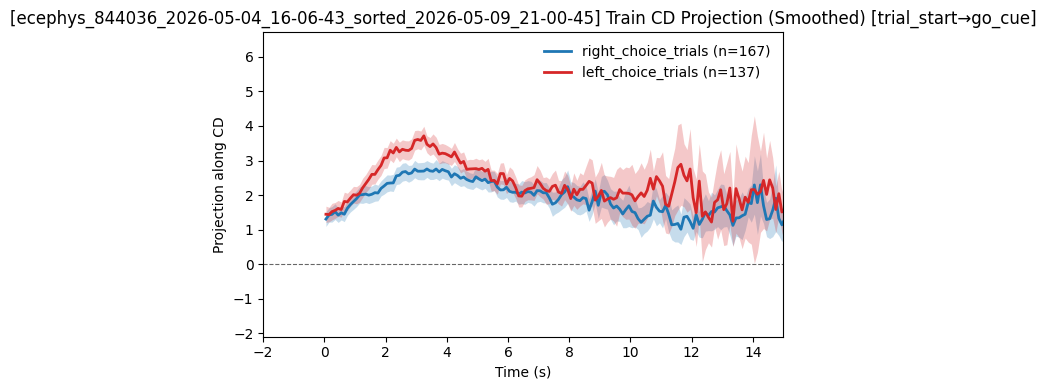

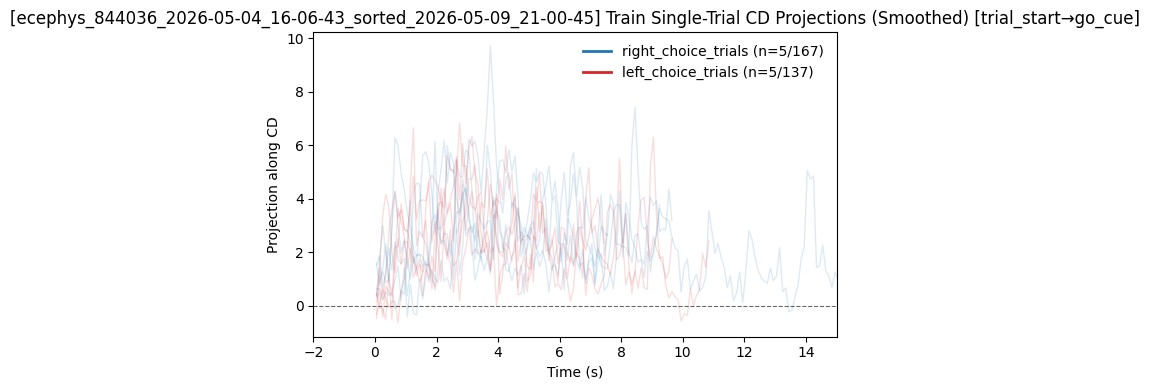

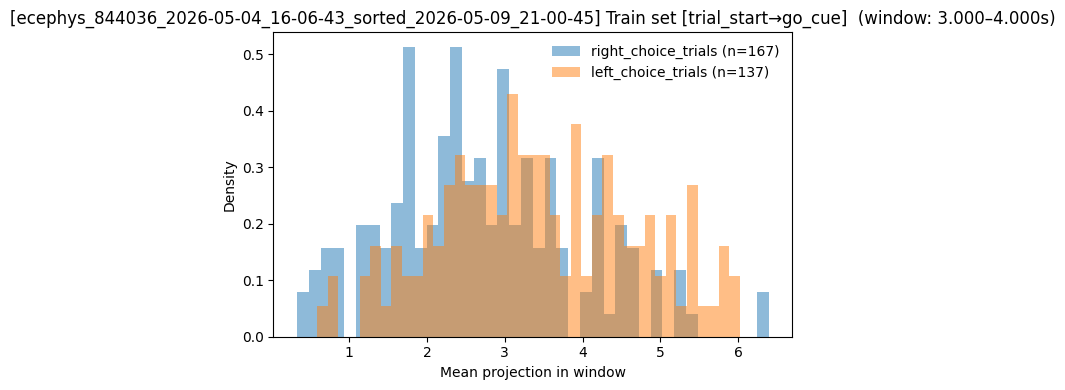


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


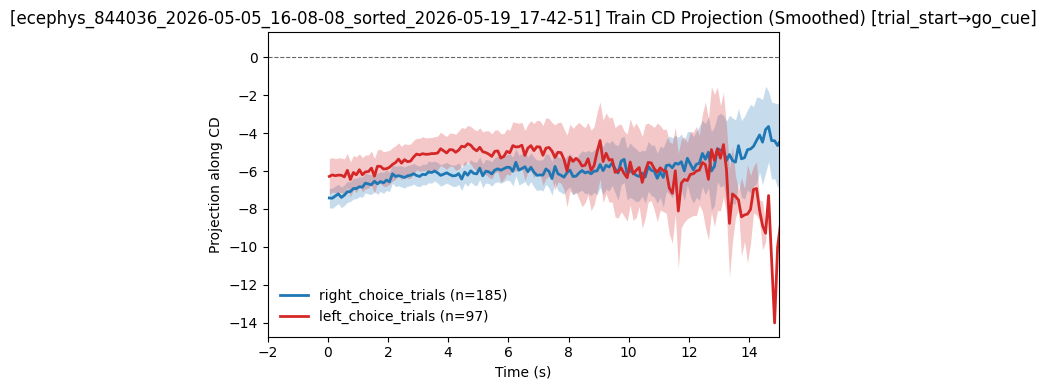

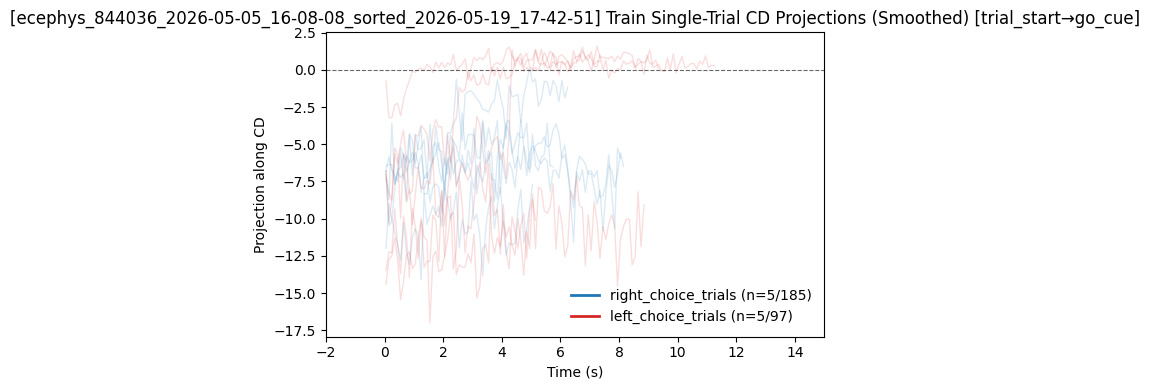

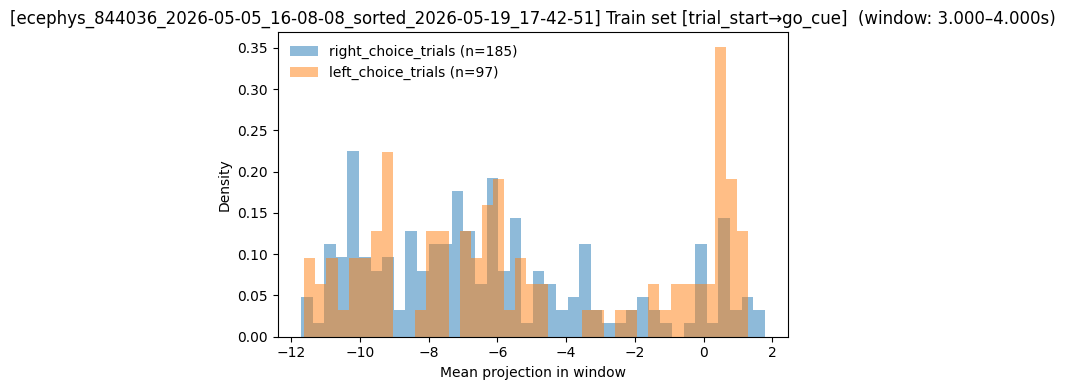


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_right_choice_trials_left_choice_trials_TW_0_0_ALIGN_trial_start_AXIS_common_action_E_0.0_1.0_L_3.0_4.0.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


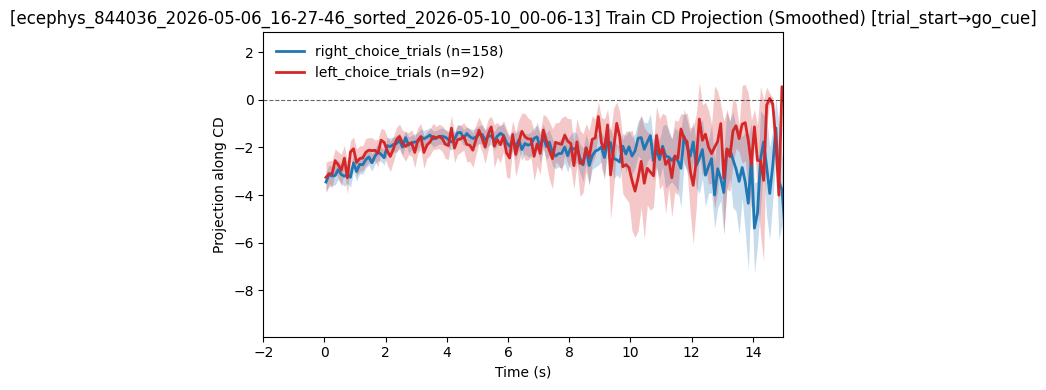

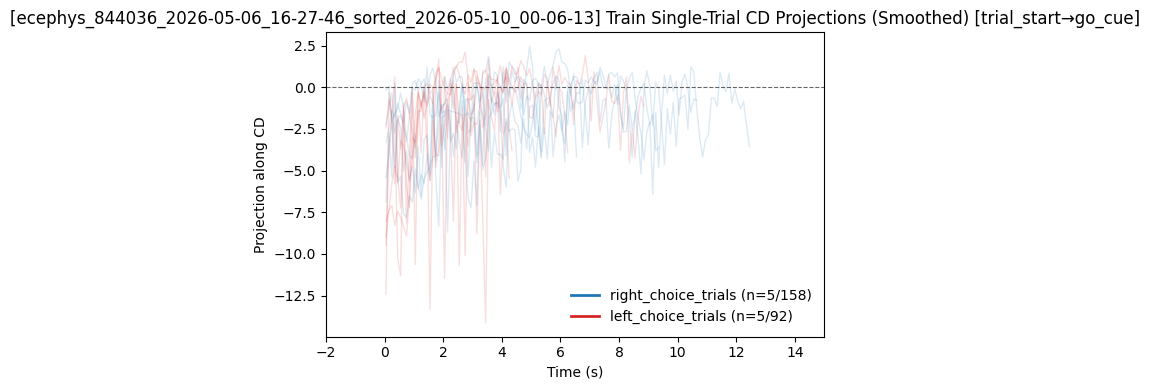

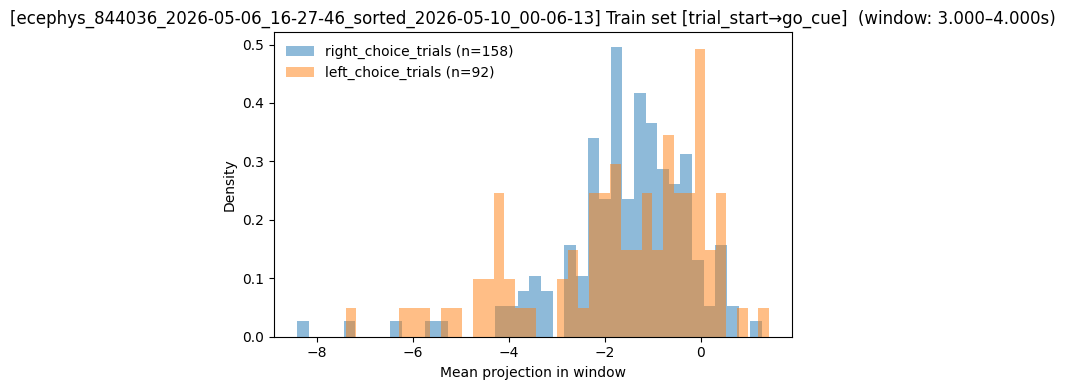

In [14]:
# =============================================================================
# Per-session COMMON-ACTION axis visualization
# Same plot_cd_session as before, but pointed at the common-action zarrs.
# A vs B split uses trial_types; axis itself is trial-type-agnostic.
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session, region_label,
)

cd_root       = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

# Must match what you passed to the common-action build cell above
ca_align              = "trial_start"
ca_trial_types        = ("right_choice_trials", "left_choice_trials")
ca_time_window        = (0, 0)                  # bookkeeping window from build
ca_early_time_window  = (0.0, 1.0)
ca_late_time_window   = (3.0, 4.0)
ca_restrict_events    = ("trial_start", "go_cue")
viz_region_group      = []

region_lbl, region_print = region_label(viz_region_group)
print(
    f"Viewing common-action axis: {region_lbl} ({region_print}), "
    f"align={ca_align}, early={ca_early_time_window}, late={ca_late_time_window}"
)

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, ca_trial_types, ca_time_window,
        align=ca_align,
        axis_mode="common_action",
        early_time_window=ca_early_time_window,
        late_time_window=ca_late_time_window,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] common-action zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_session(
        sess,
        distribution_window=ca_late_time_window,   # AUC/dist panel uses late window
        restrict_events=ca_restrict_events,
        restrict_align=ca_align,
        xlim=(-2, 15),
        split="train",
        smooth_gauss=0.0,
        smooth_moving_window=5,
        plot_single_trial=True,
        random_sample_trial_N=5,
    )


Viewing region: RG_ALL (ALL), TW=(-1, 0), align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


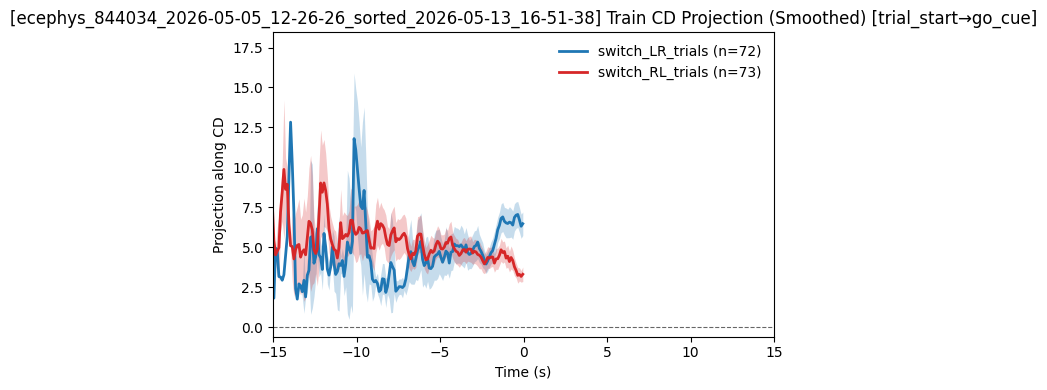

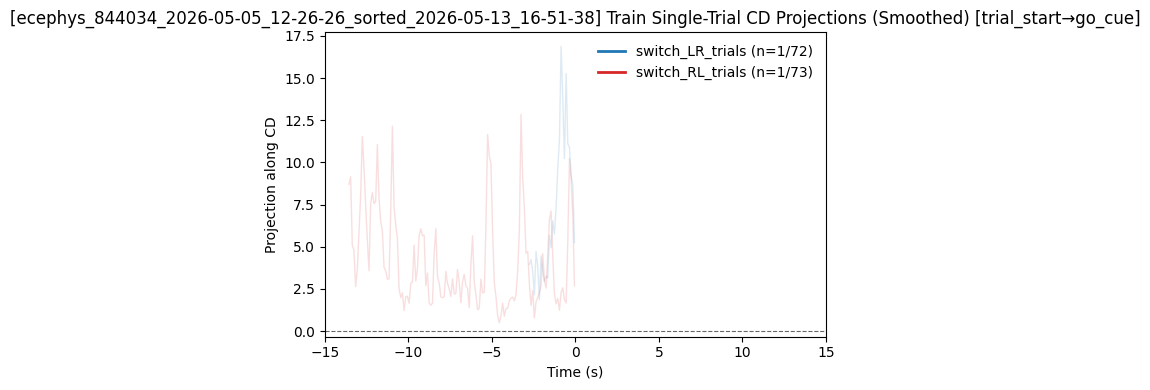

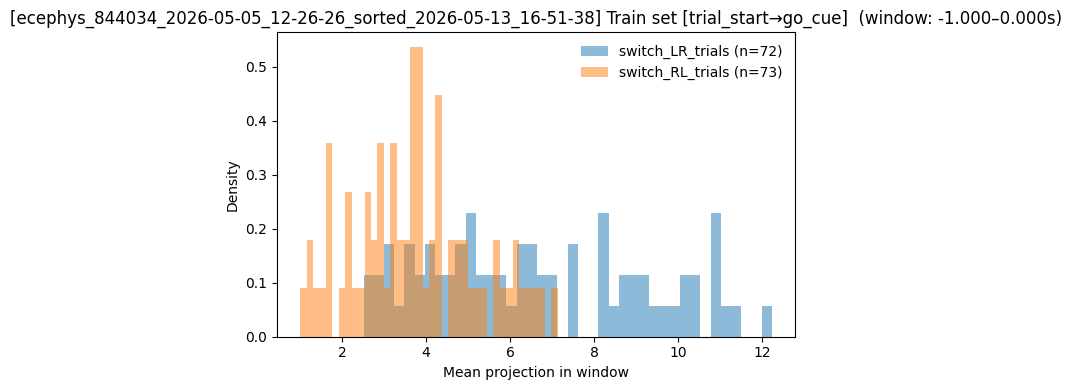


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


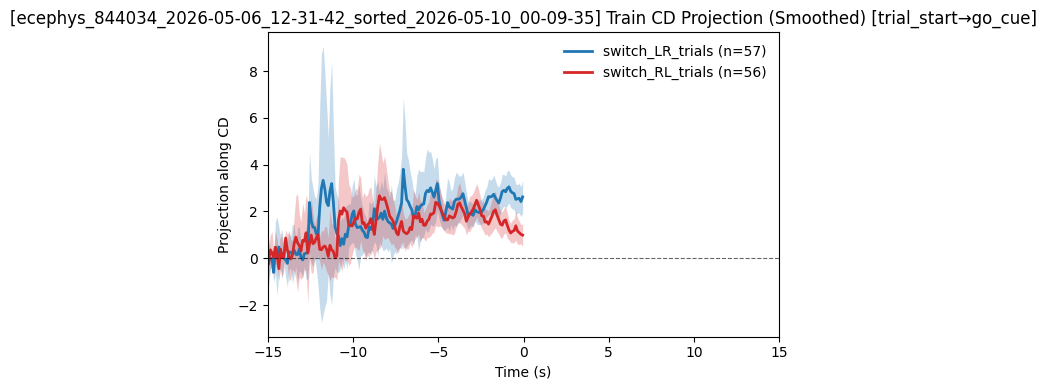

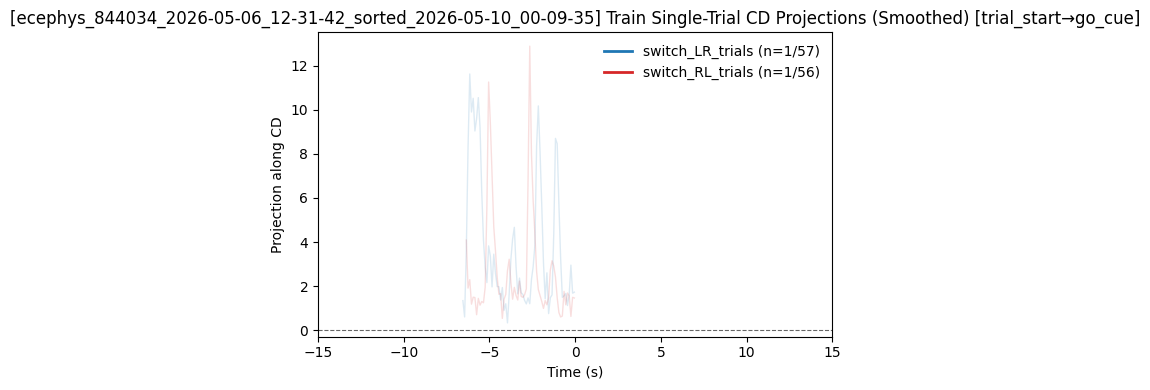

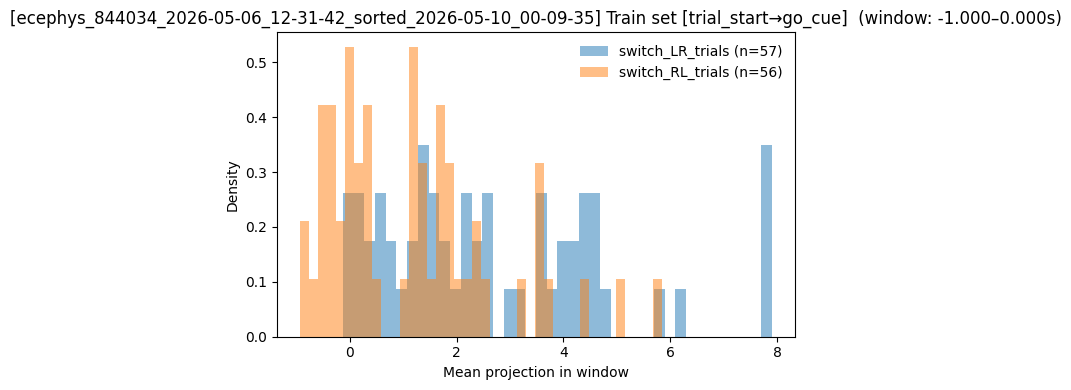


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


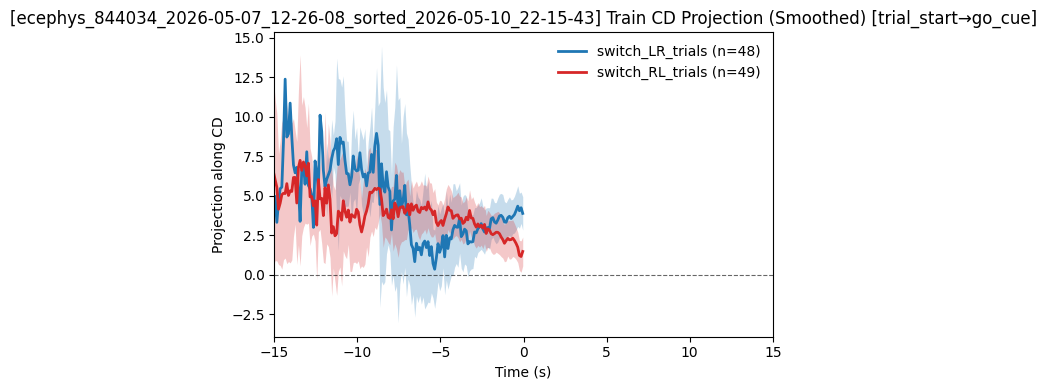

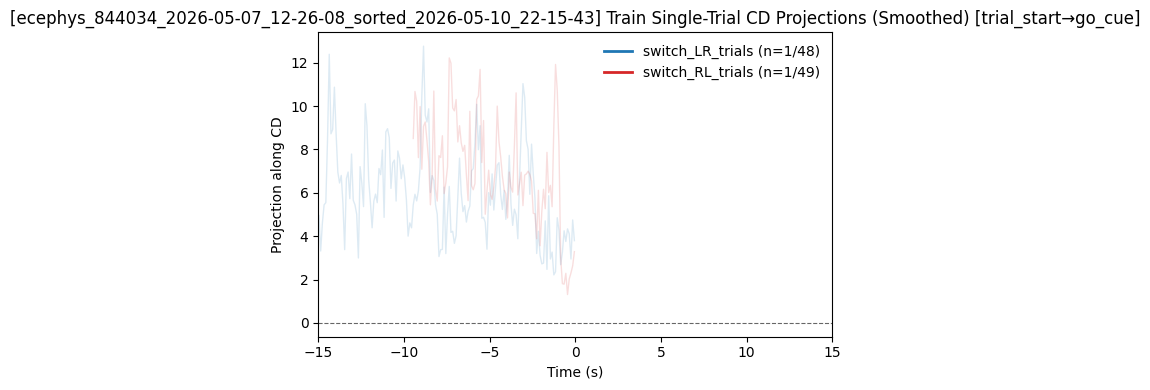

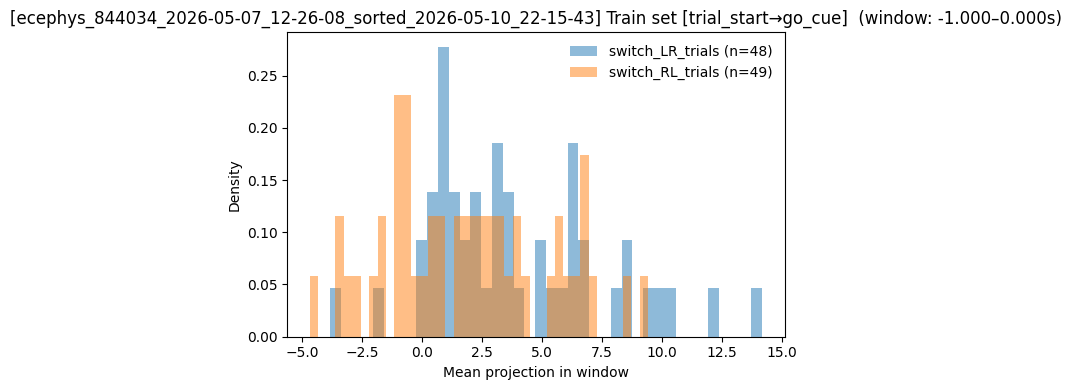


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


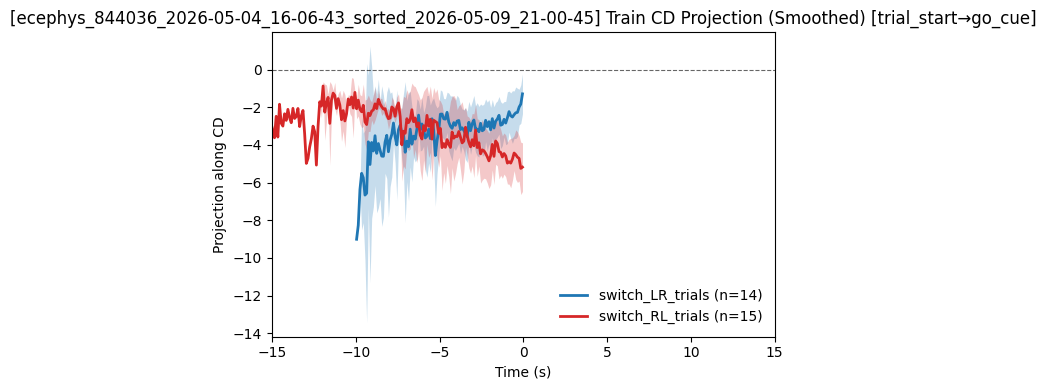

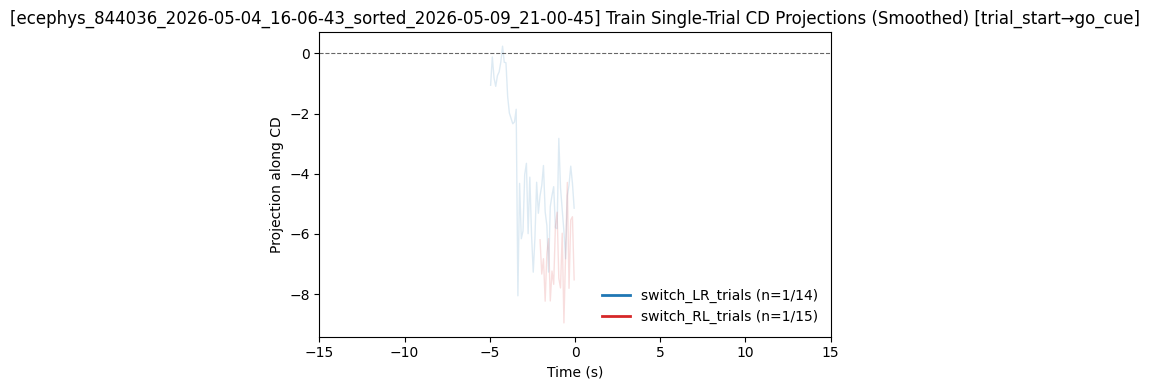

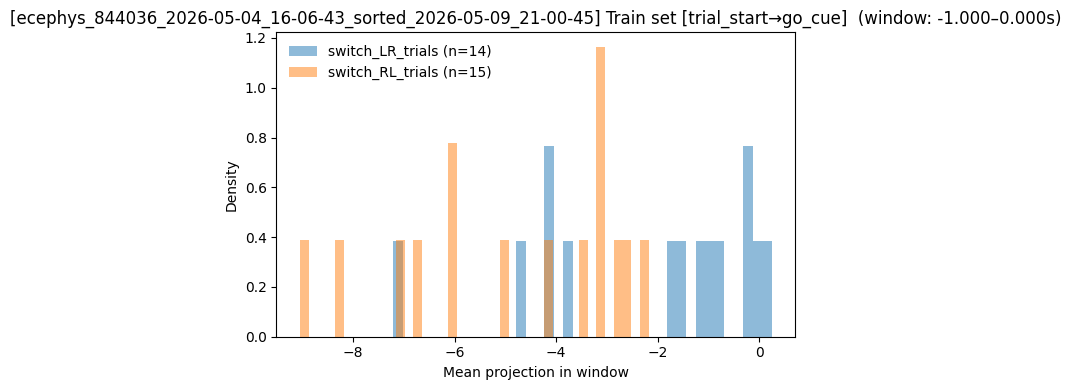


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


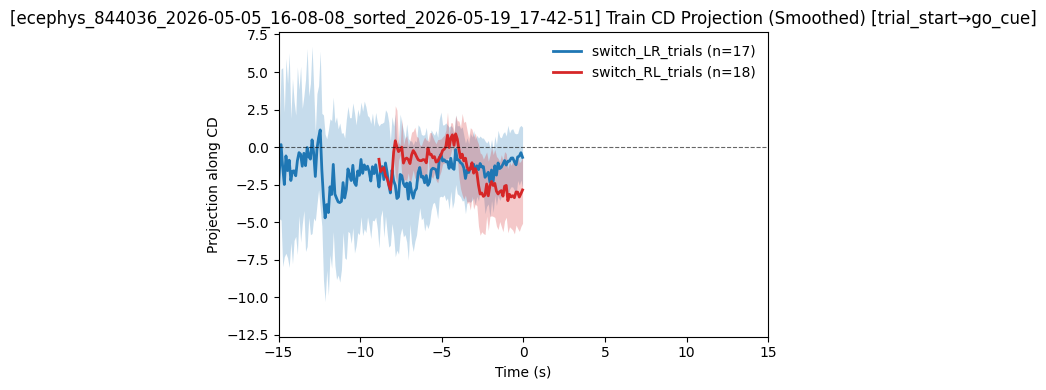

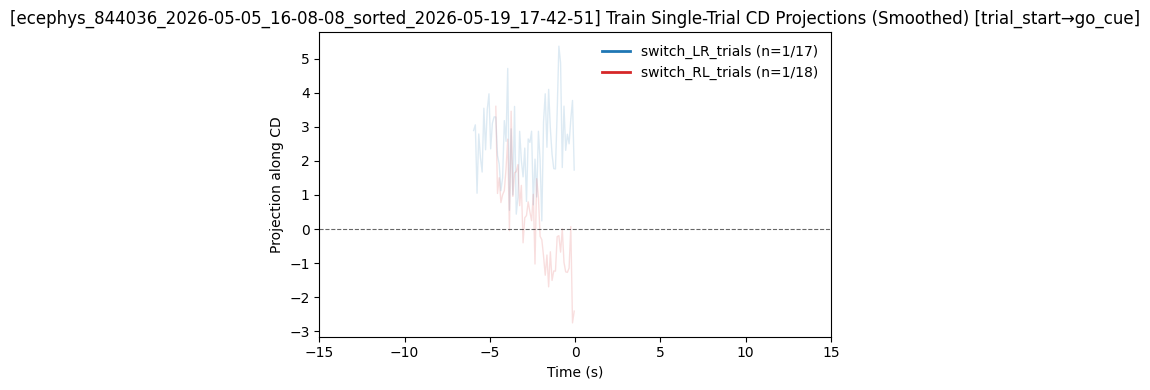

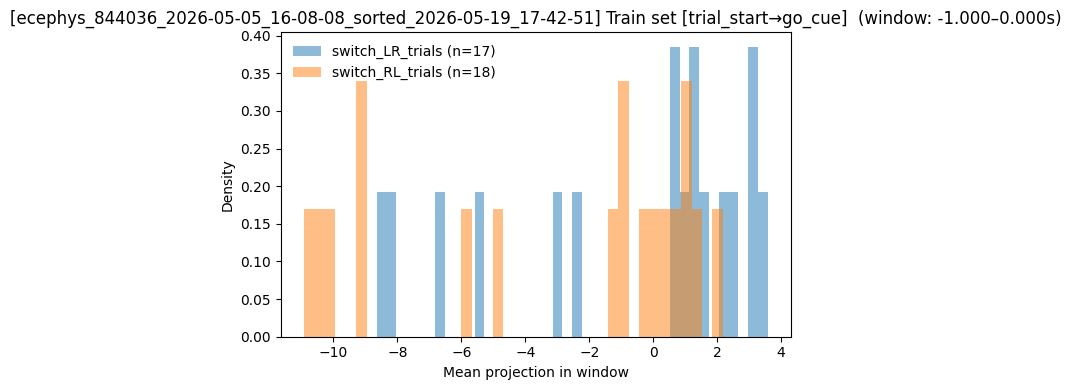


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


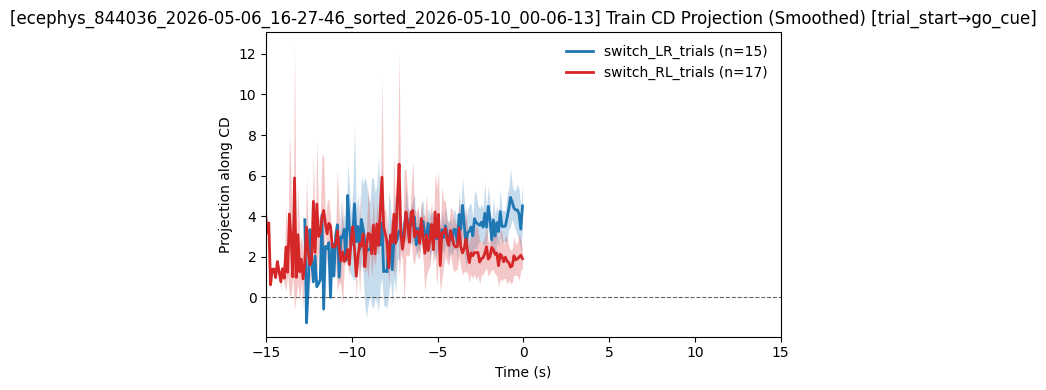

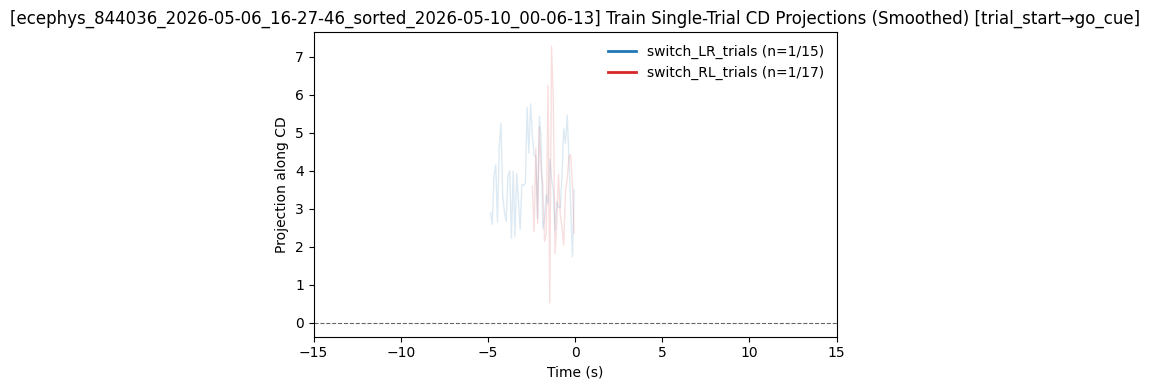

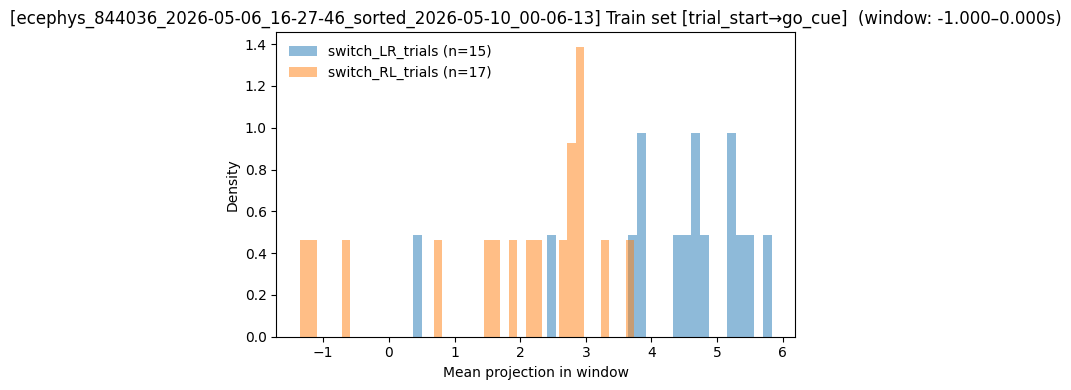

In [4]:
# Per-session CD plots (one figure set per session)
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

# Pick which region group + time-window combo to visualize per session.
# Must match one of the combos produced by the build cell.
viz_region_group = []            # [] => all units (matches RG_ALL files)
viz_time_window = (-1, 0)
distribution_window = (-1, 0)

# Optional: restrict each trial to its own [event_start, event_end] interval.
# Useful when align="trial_start" and ITI varies — averages then ignore
# samples after each trial's go_cue. Set to None to disable.
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,   # None to disable
        restrict_align=align,              # CD axis time is relative to this
        xlim=(-15,15),
        #trial_types=["right_choice_trials", "left_choice_trials"],
        #trial_types=["right_rewarded_trials", "right_unrewarded_trials"],
        split='train',
        smooth_gauss=0.0,           # disable mean-trace smoothing
        smooth_moving_window=5,     # disable single-trial boxcar
        plot_single_trial=True,
        random_sample_trial_N=1,    # show 20 random trials per class
        #random_sample_seed=1, 
    )




Viewing region: RG_ALL (ALL), TW=(-1, 0), align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


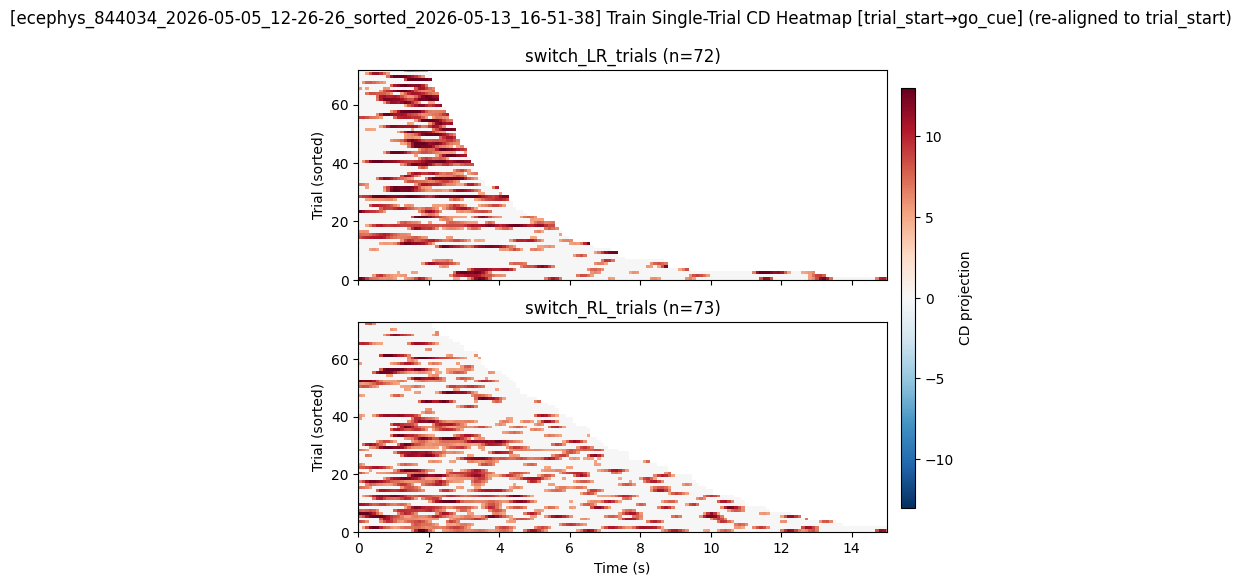

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


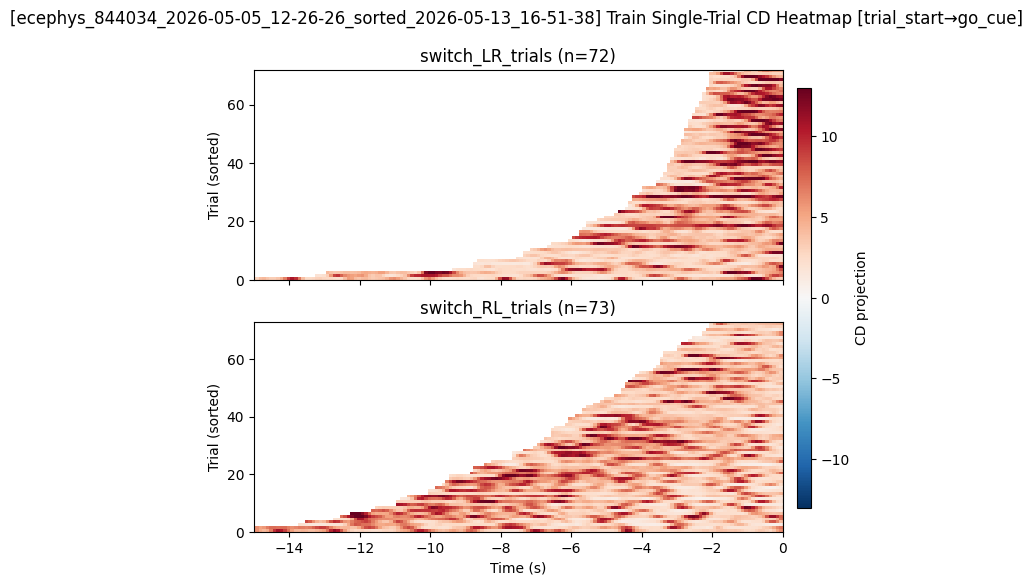


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


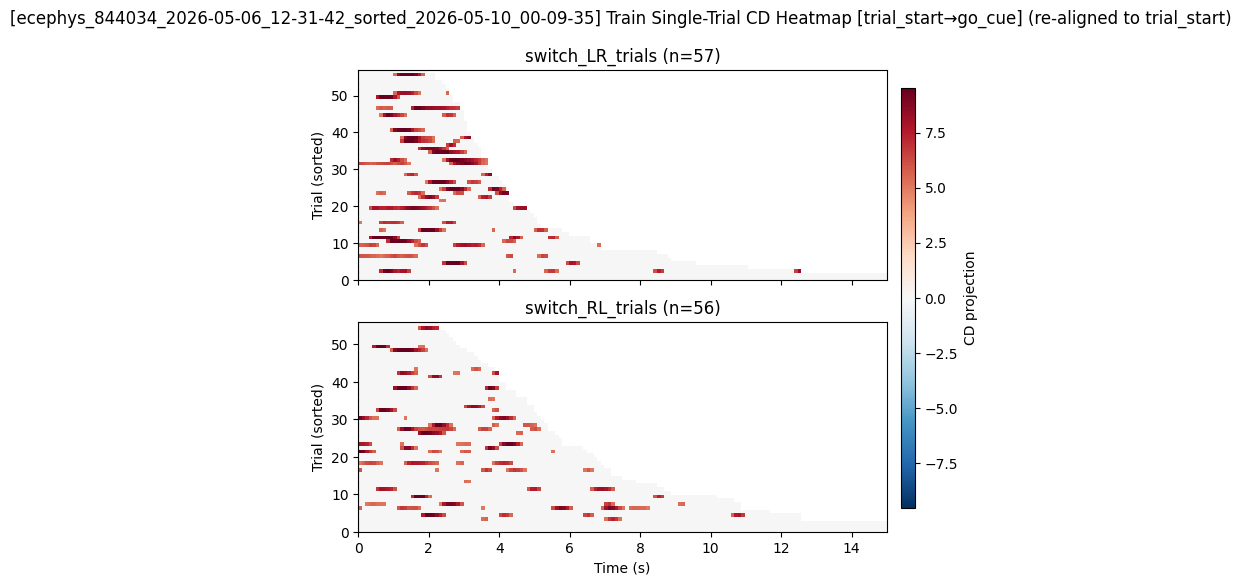

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


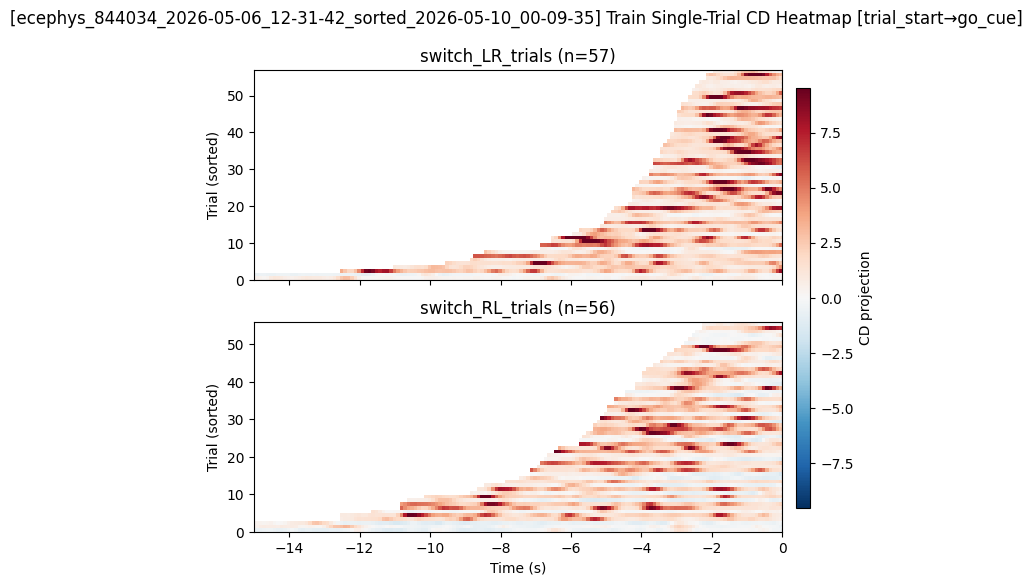


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


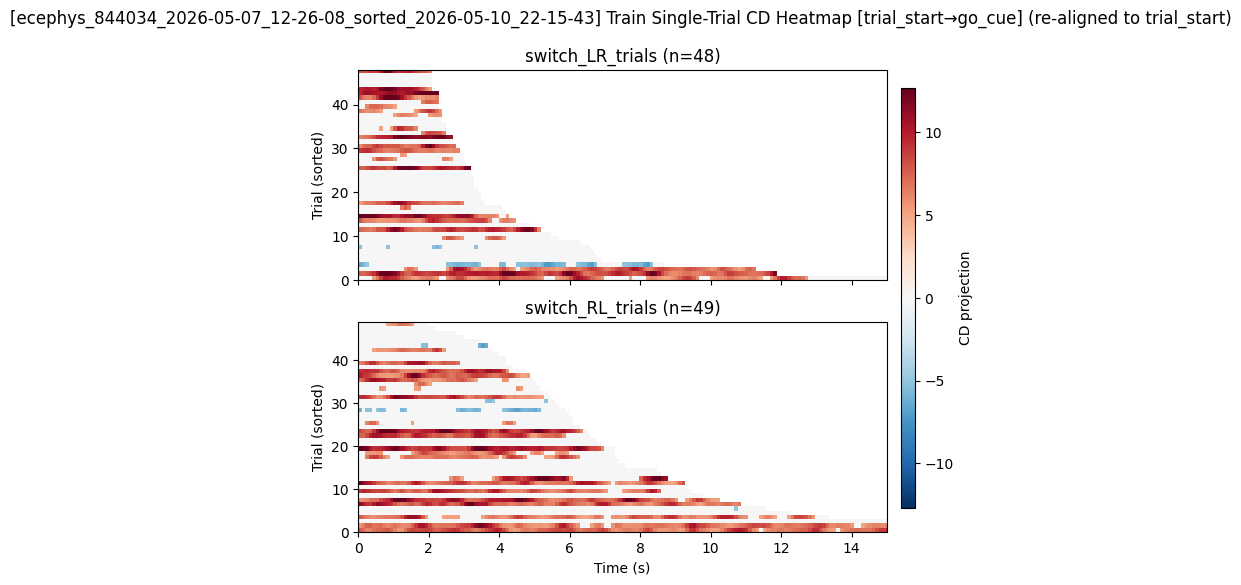

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


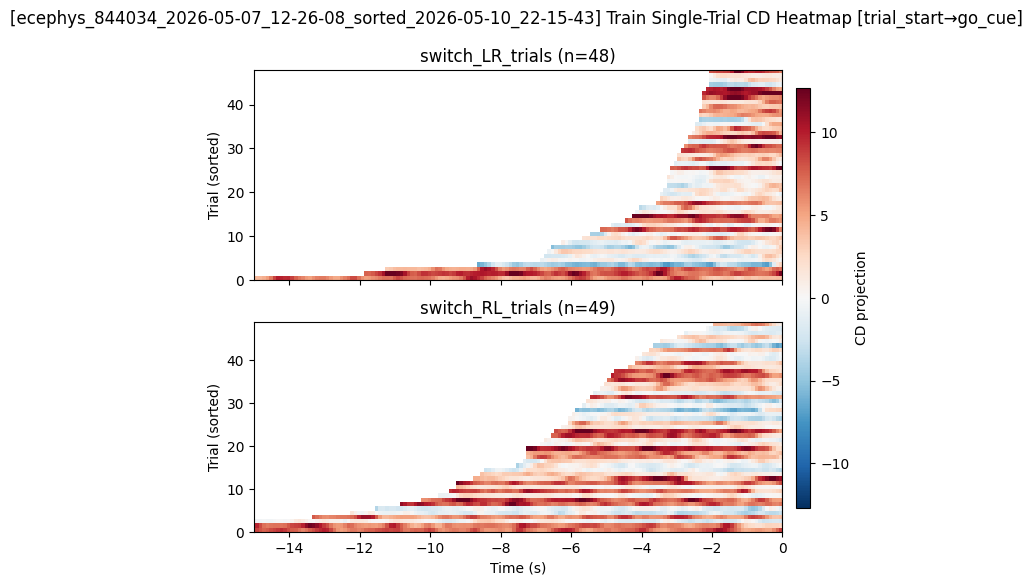


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


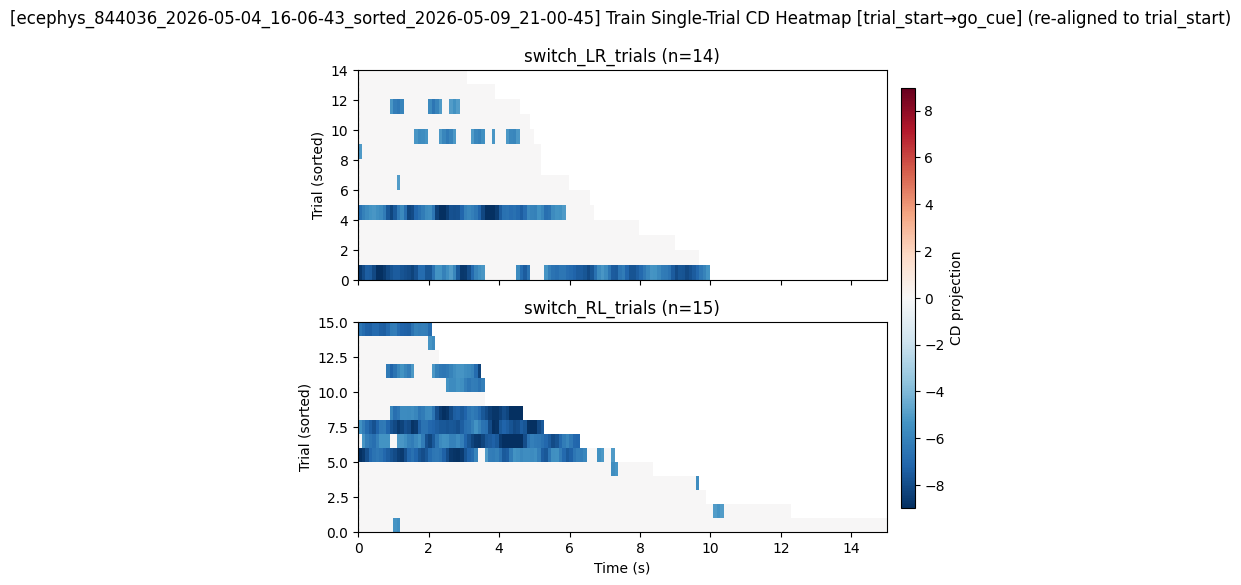

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


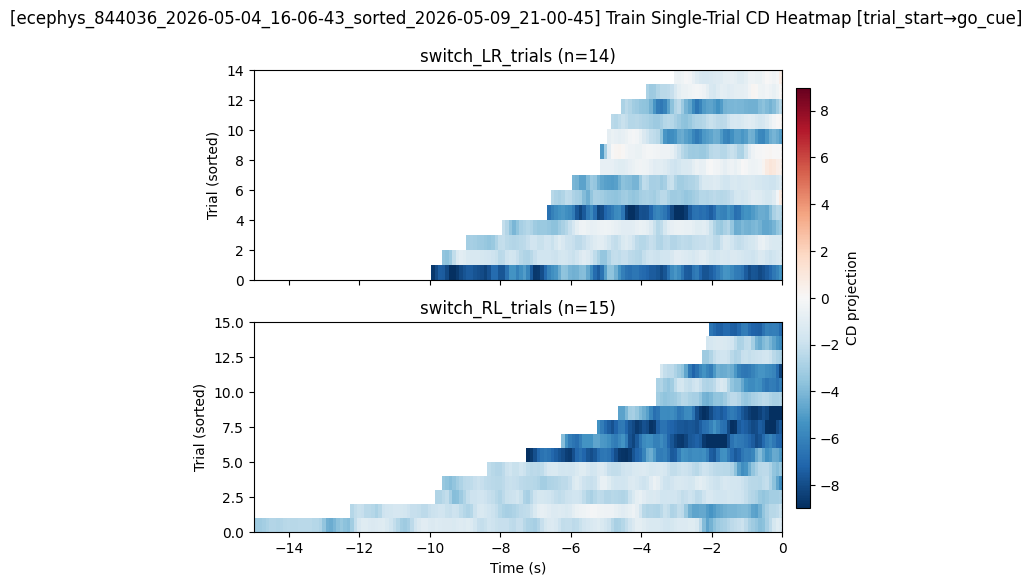


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


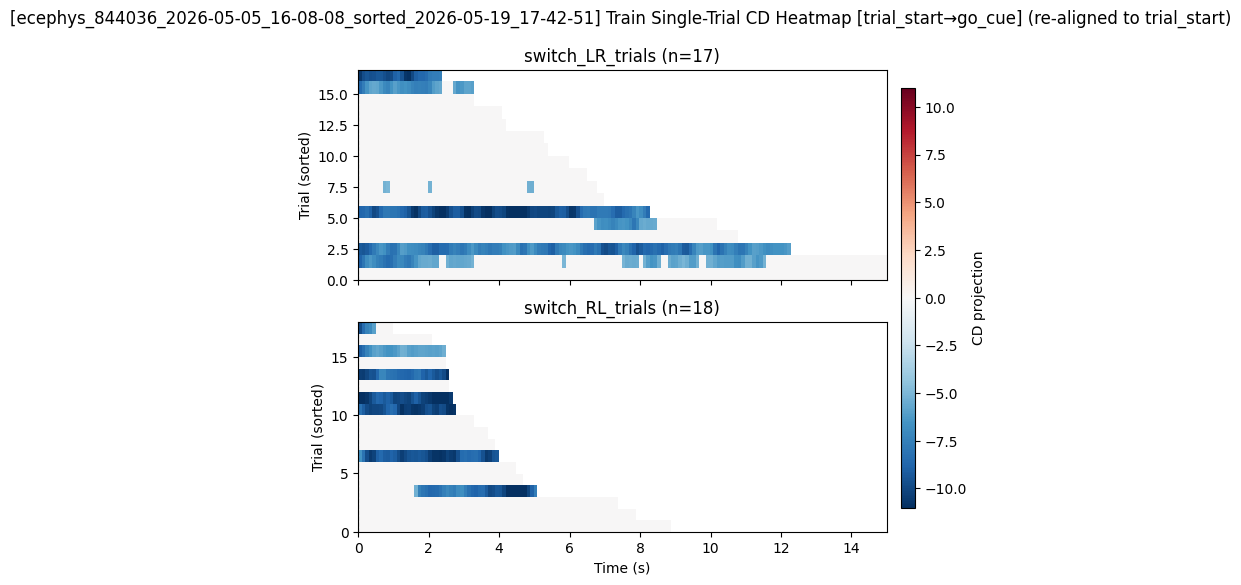

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


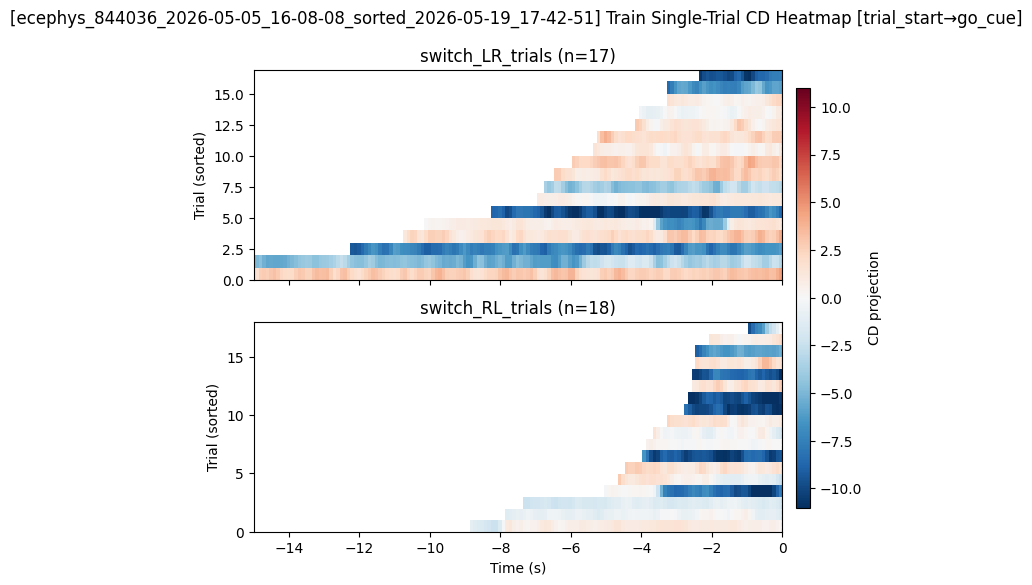


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


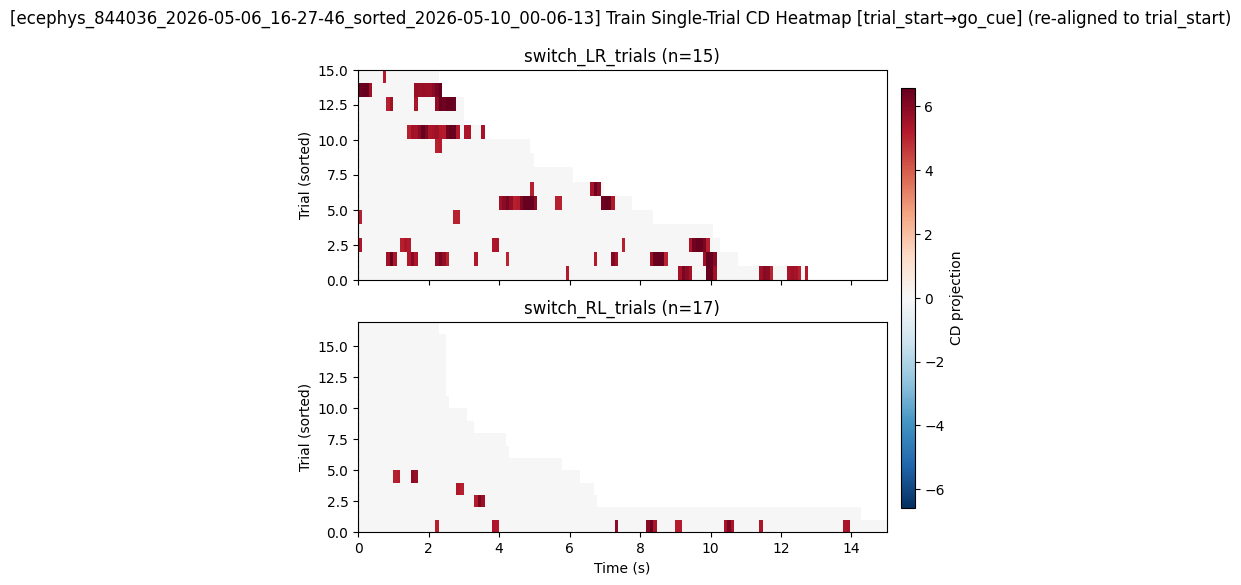

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


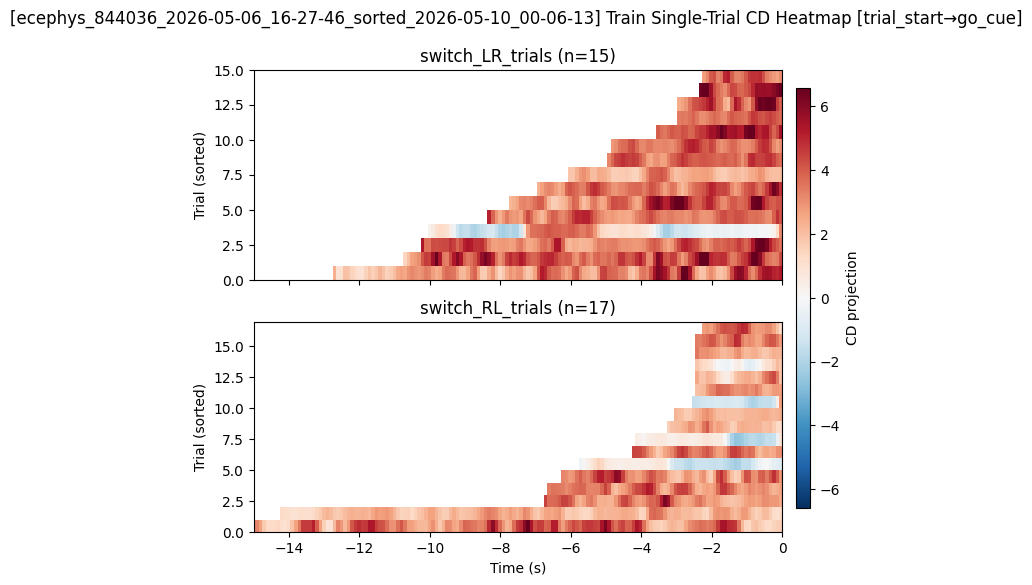

In [15]:
# =============================================================================
# Per-session SINGLE-TRIAL CD HEATMAPS
# Each panel = one class; rows = trials sorted by their averaged projection
# in `sort_window`. Mirrors plot_cd_session for trial selection and smoothing.
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session_heatmap, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

viz_region_group = []
viz_time_window = (-1, 0)
trial_types            = ("switch_LR_trials", "switch_RL_trials")
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)

    # Example 1: rewarded vs unrewarded right-choice trials, sort by mean
    # projection in the CD-fit window.
    plot_cd_session_heatmap(
        sess,
        #trial_types=["switch_LR_trials", "switch_RL_trials"],
        #trial_types=["right_choice_trials", "left_choice_trials"],
        smooth_gauss=0.1,
        sort_by="window_length",
        sort_window=(0, 15),
        xlim=(0,15),
        cmap="RdBu_r",
        symmetric_colorbar=True,
        restrict_events=restrict_events, 
        restrict_align="trial_start",   
        threshold=5,
    )

    plot_cd_session_heatmap(
        sess,
        #trial_types=["switch_LR_trials", "switch_RL_trials"],
        #trial_types=["right_choice_trials", "left_choice_trials"],
        smooth_gauss=0.1,
        sort_by="window_length",
        sort_window=(0, 15),
        xlim=(-15,0),
        cmap="RdBu_r",
        symmetric_colorbar=True,
        restrict_events=restrict_events, 
        restrict_align="go_cue",   
        threshold=0,
    )

    # Example 2: train split A vs B, sorted by peak time, with a random
    # 60-trial subsample per class for a cleaner view.
    # plot_cd_session_heatmap(
    #     sess,
    #     split="train",
    #     smooth_gauss=0.1,
    #     sort_by="peak_time",
    #     sort_window=(-1, 3),
    #     random_sample_trial_N=60,
    #     xlim=(-2, 5),
    # )


Viewing region: RG_ALL (ALL), TW=(-1, 0), align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb

[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] right_choice_trials: 260/263 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 397           2.65       2.600        3.344552     2.265041      0.696574   0.635234     4.198912   -3.650632
     pos 602           2.35       2.575        9.197079     3.709539      0.503226   0.401113     5.432886    4.540761


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


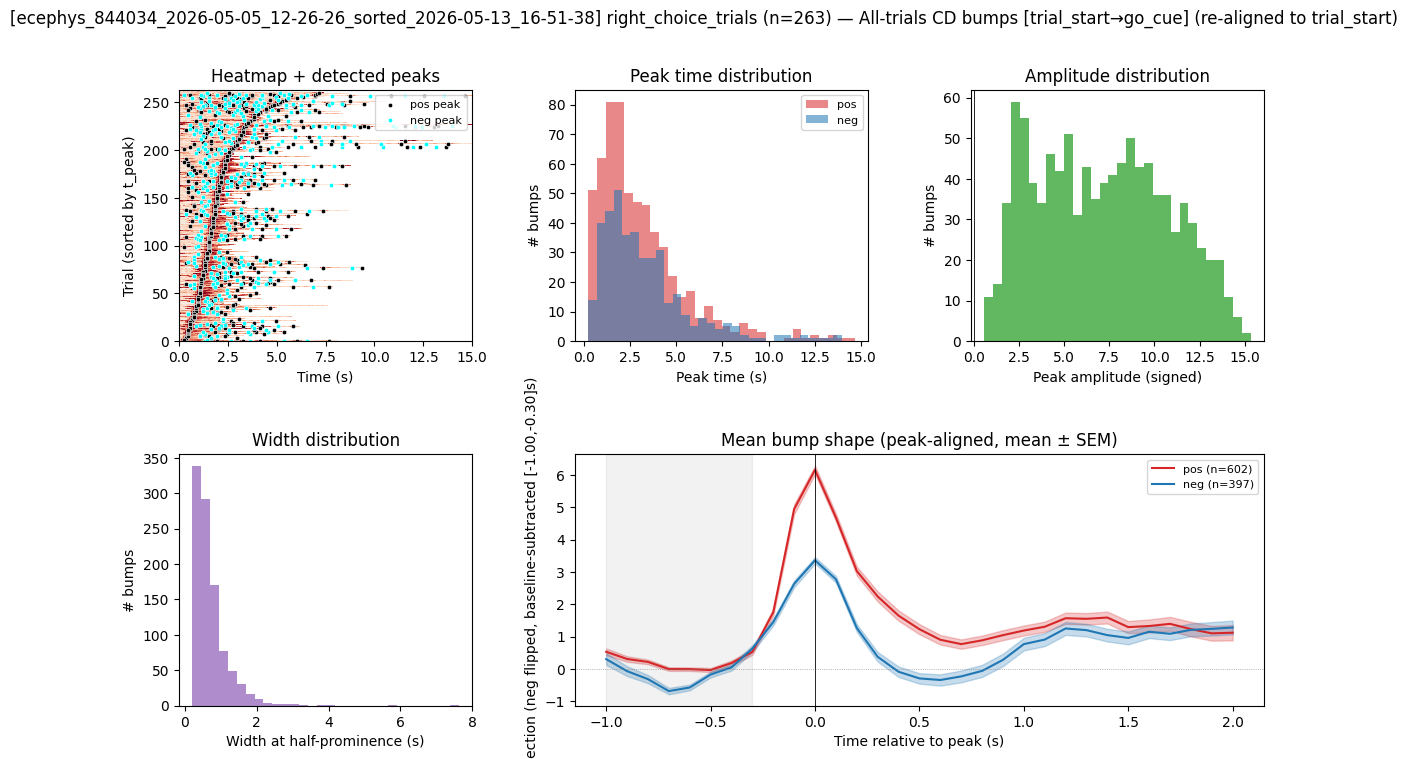

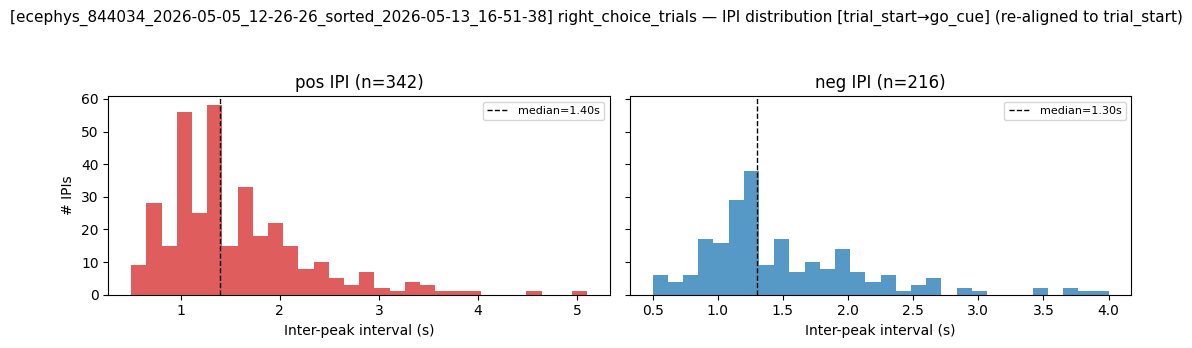

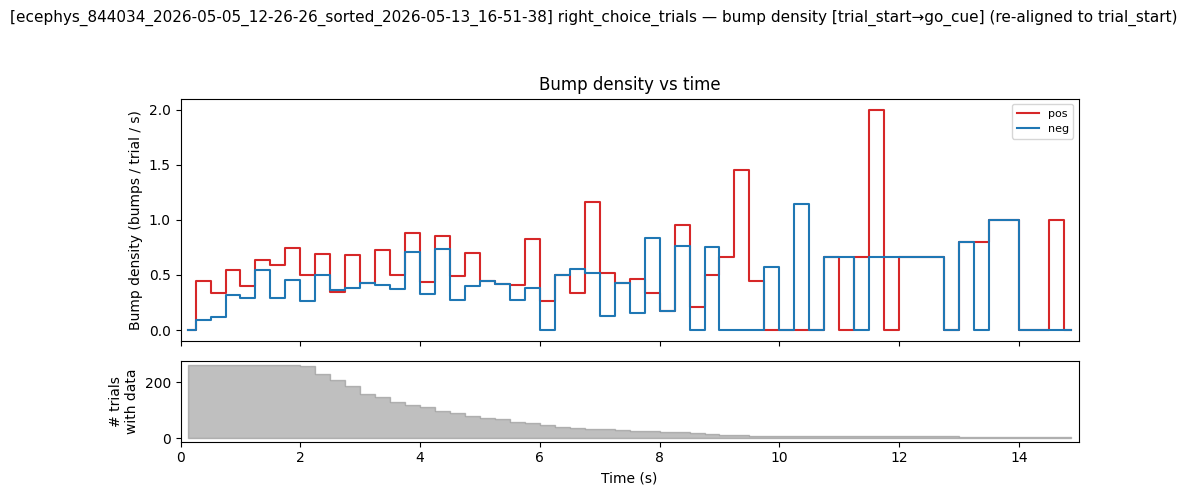


[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] left_choice_trials: 248/268 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 467           3.55        3.55        2.985705     1.913484       0.93603   0.904918     4.503828   -4.096610
     pos 665           3.25        3.70        9.542242     5.089006       0.48244   0.290002     5.769826    4.366692


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


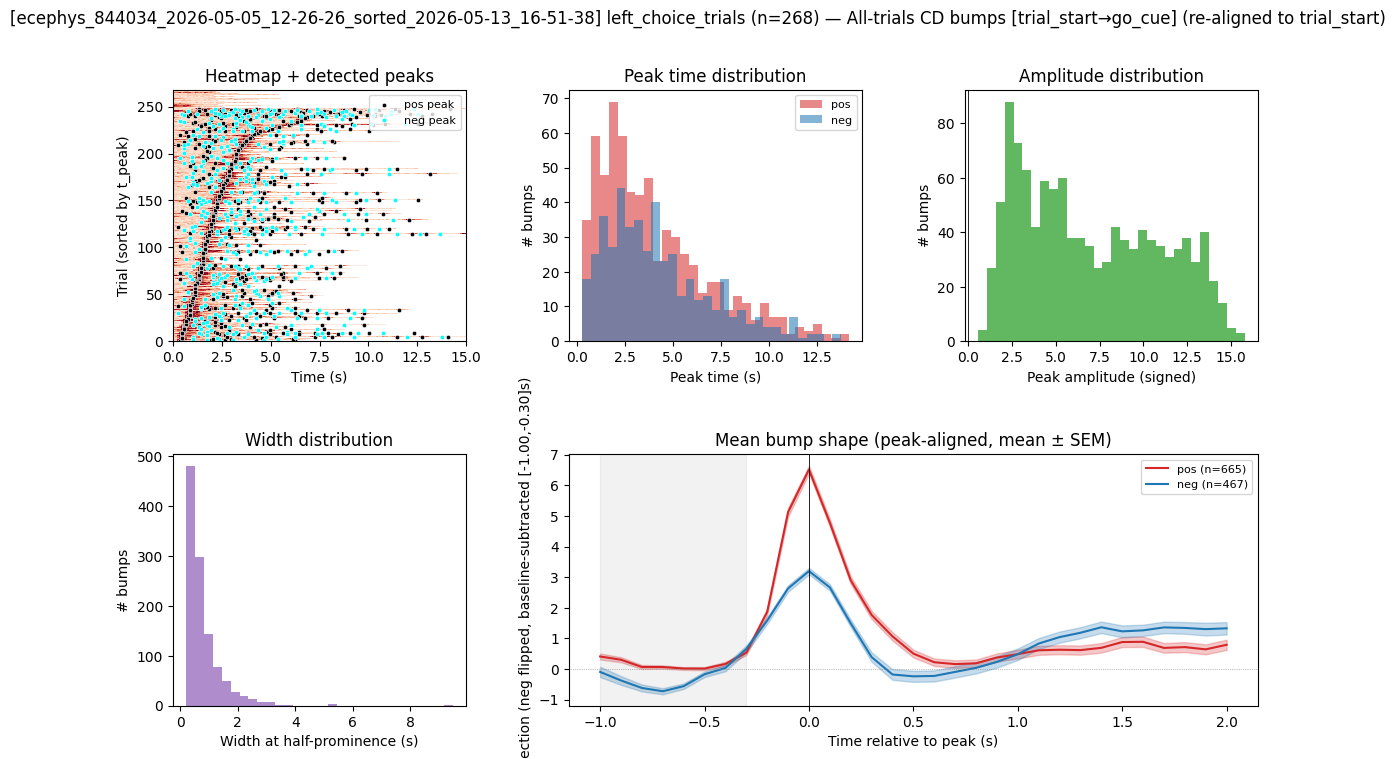

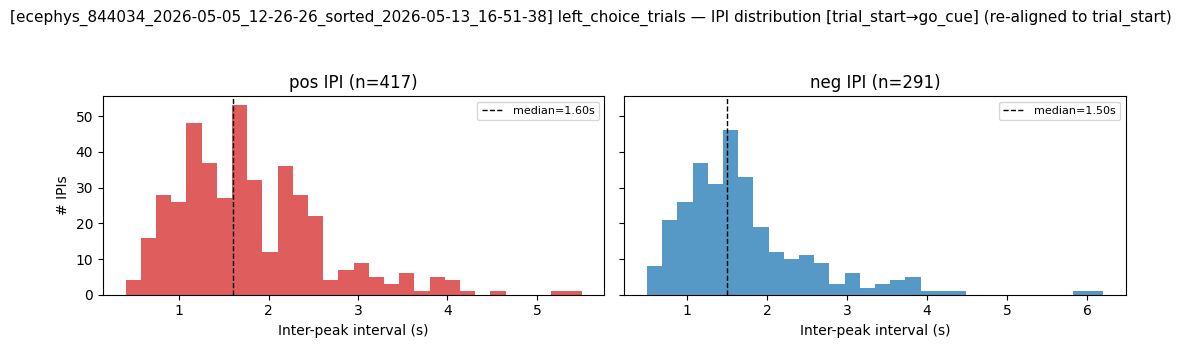

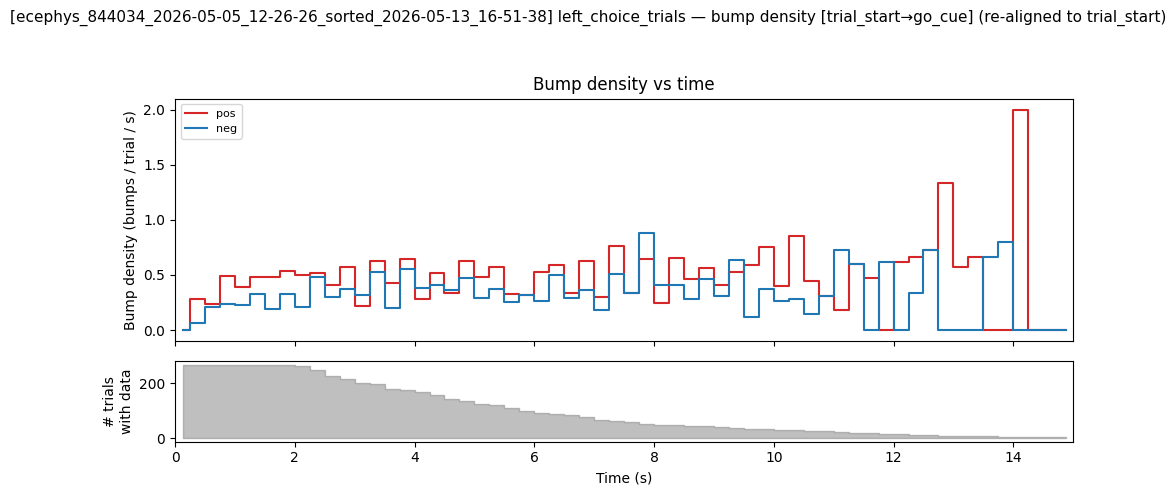


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb

[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] right_choice_trials: 202/223 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 210           3.60         3.1        1.102016     0.880689      1.081399   1.129858     3.521356   -2.527754
     pos 382           2.75         3.2        6.124633     3.487645      0.516743   0.263610     4.963940    2.927057


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


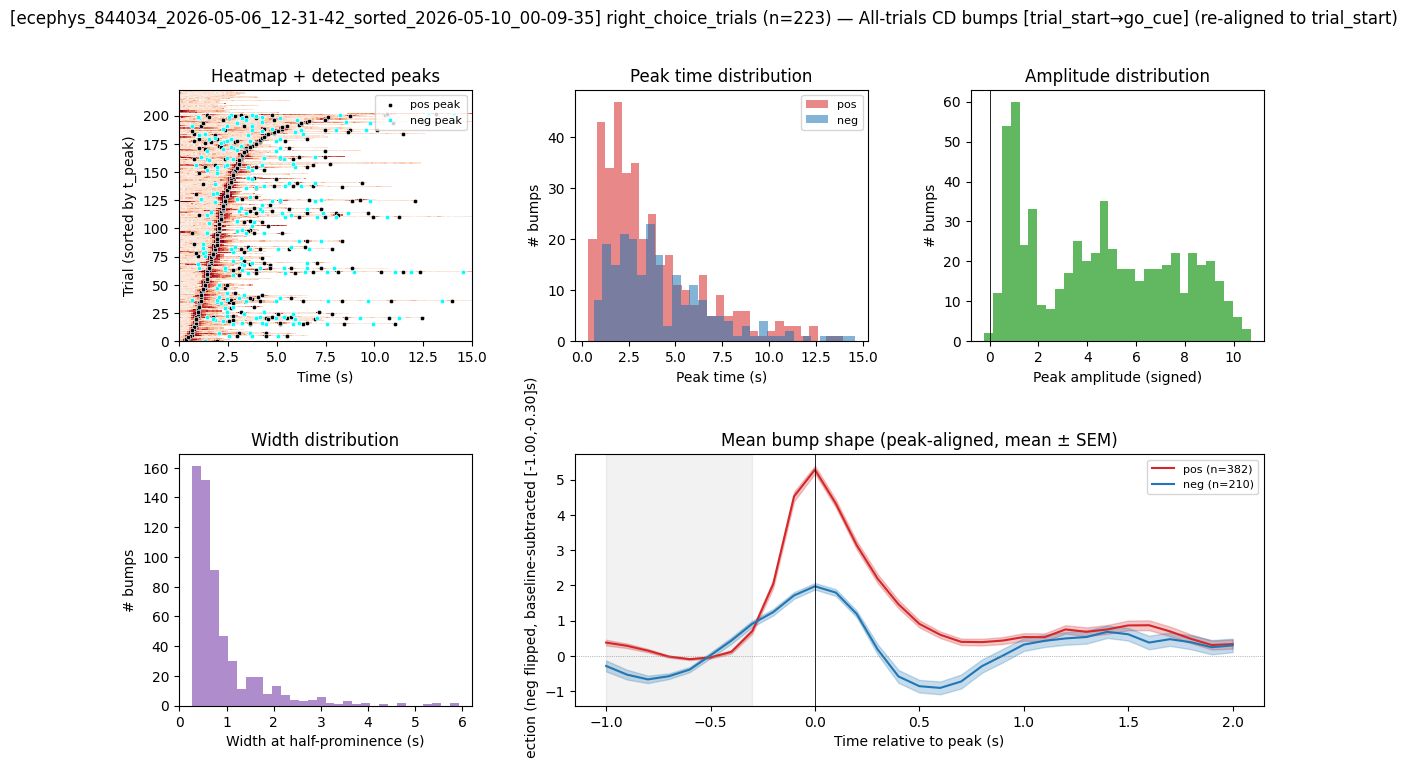

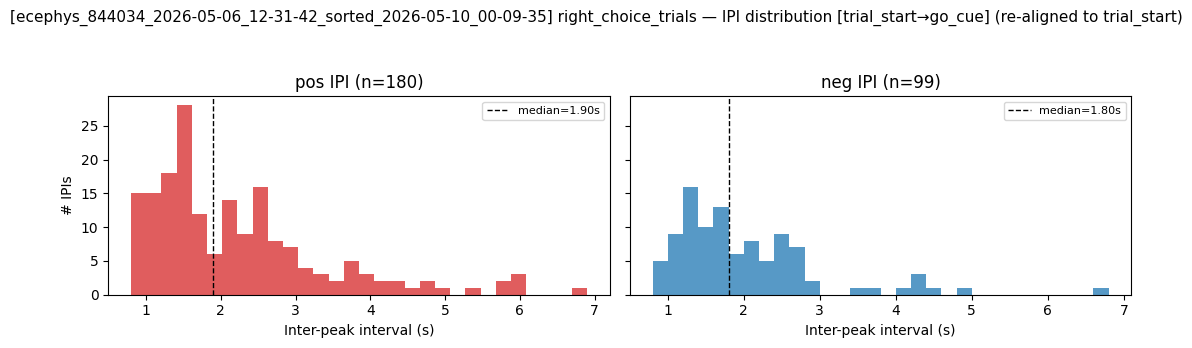

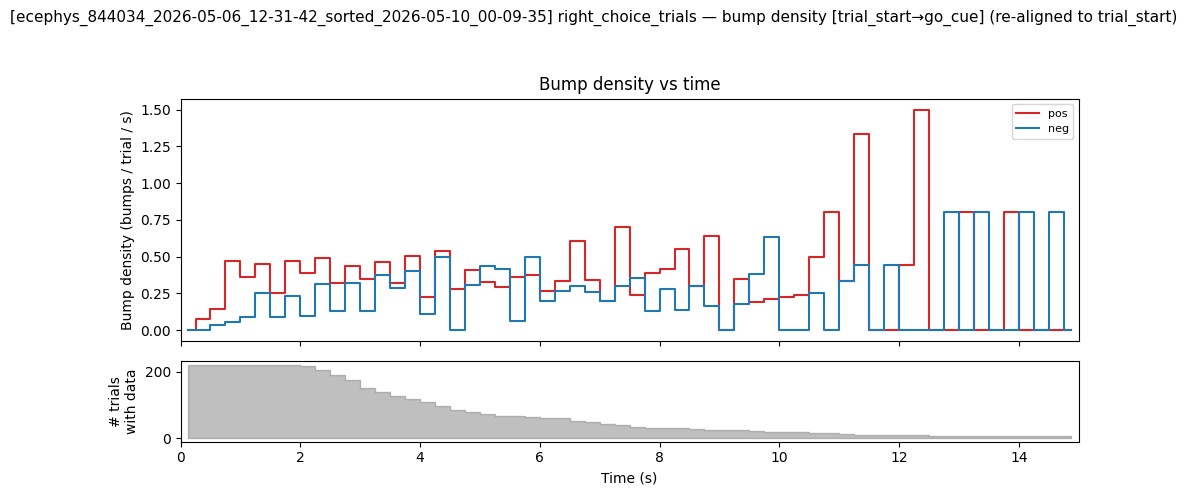


[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] left_choice_trials: 279/295 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 431           3.55         3.1        1.280680     0.880471      1.090272   0.967806     3.759735   -2.451924
     pos 634           3.05         3.5        6.561071     3.491641      0.487886   0.239213     4.976165    2.958886


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


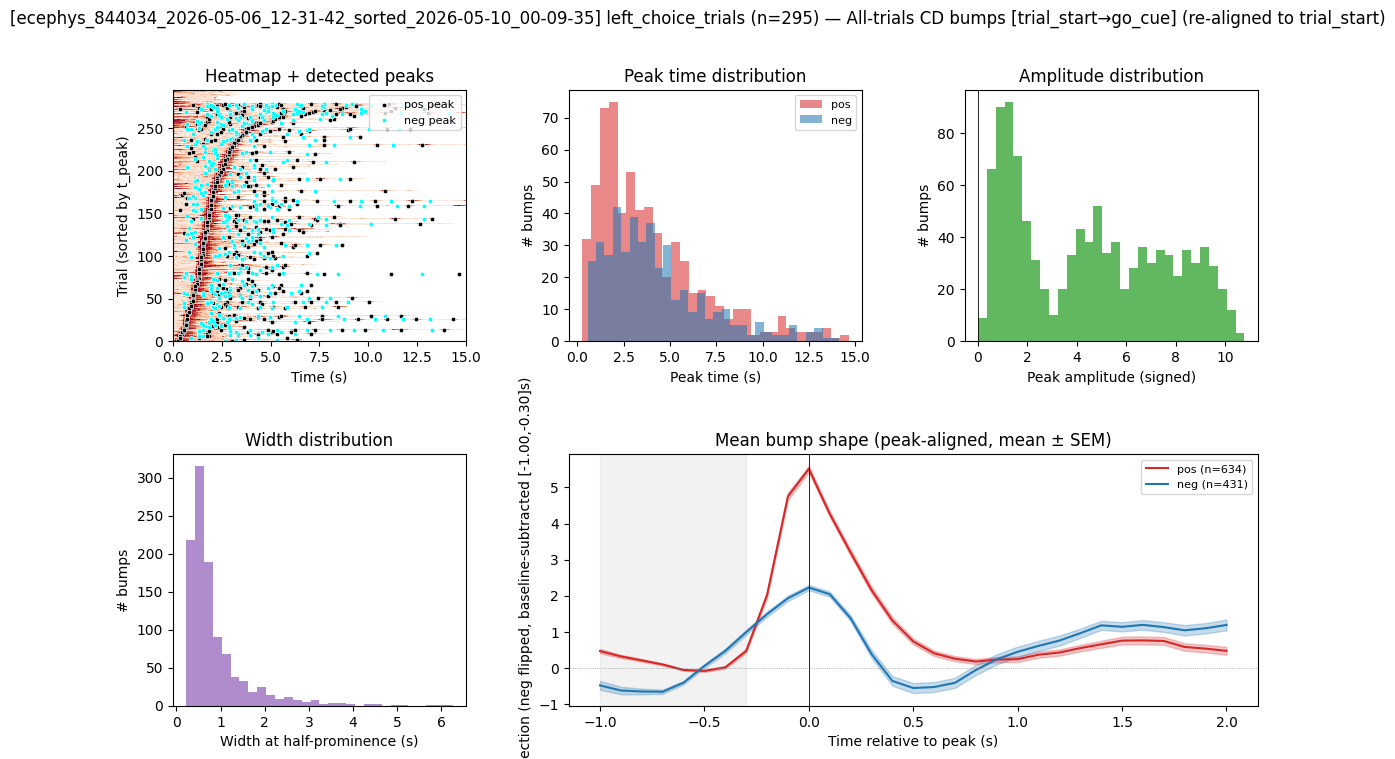

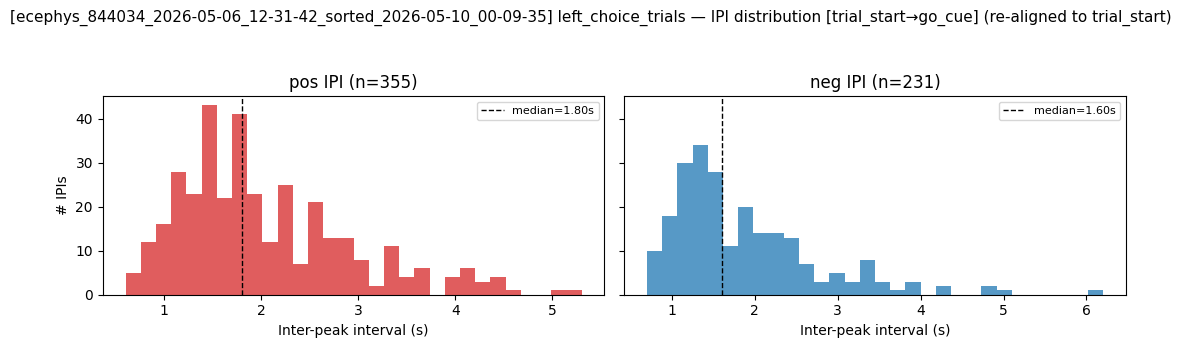

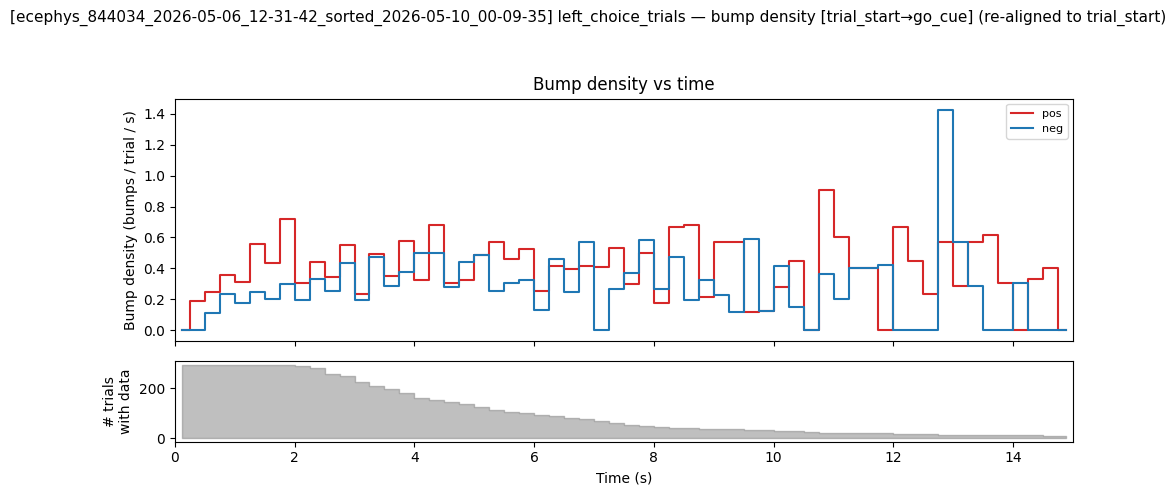


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb

[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] right_choice_trials: 198/206 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 286           2.85       3.000        2.801183     1.418766      0.706388   0.514529     3.068553   -2.766872
     pos 430           2.45       3.075        6.652921     1.935873      0.560057   0.338757     4.051967    3.680906


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


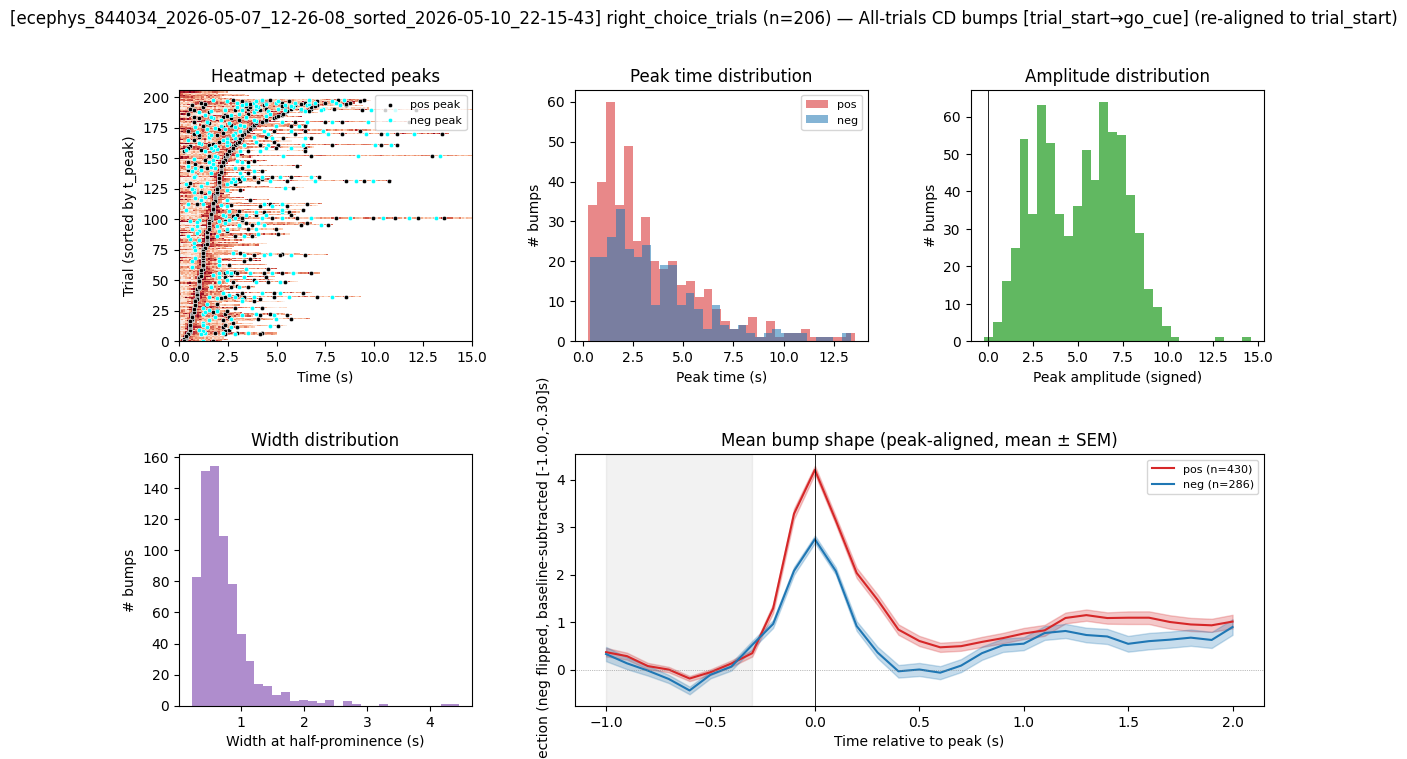

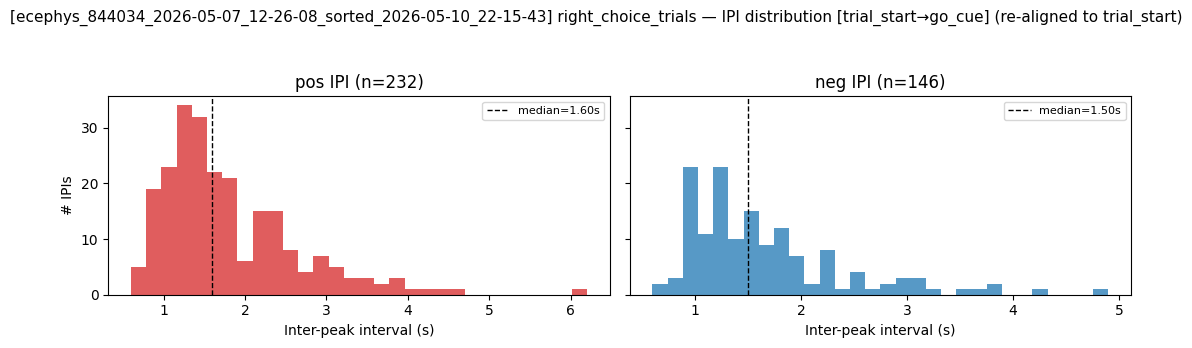

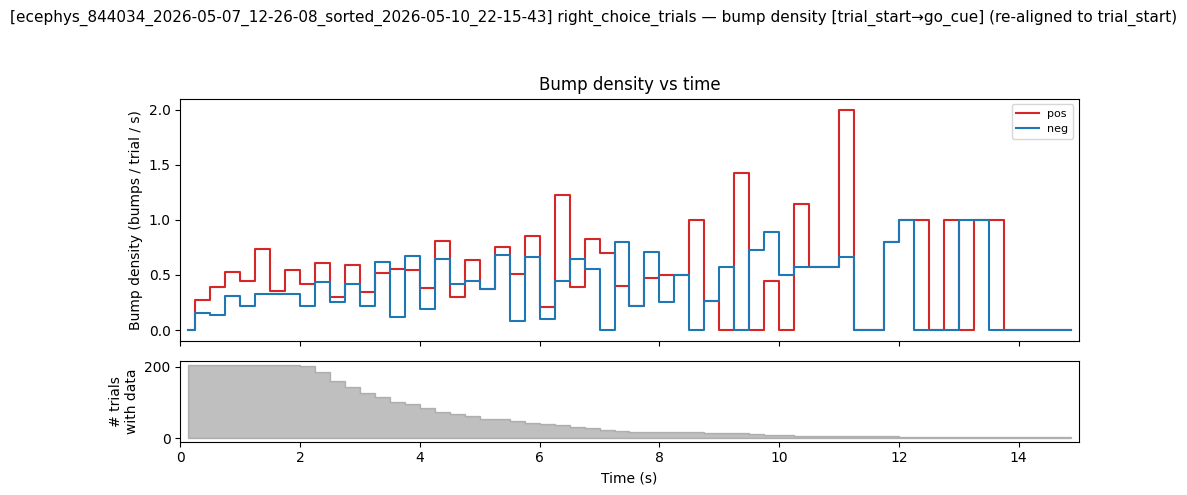


[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] left_choice_trials: 312/332 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 616           3.35         3.8        2.286925     1.346360      0.763479   0.499375     3.117731   -2.517627
     pos 841           3.15         3.8        6.101174     1.832699      0.517371   0.289621     3.722476    3.107886


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


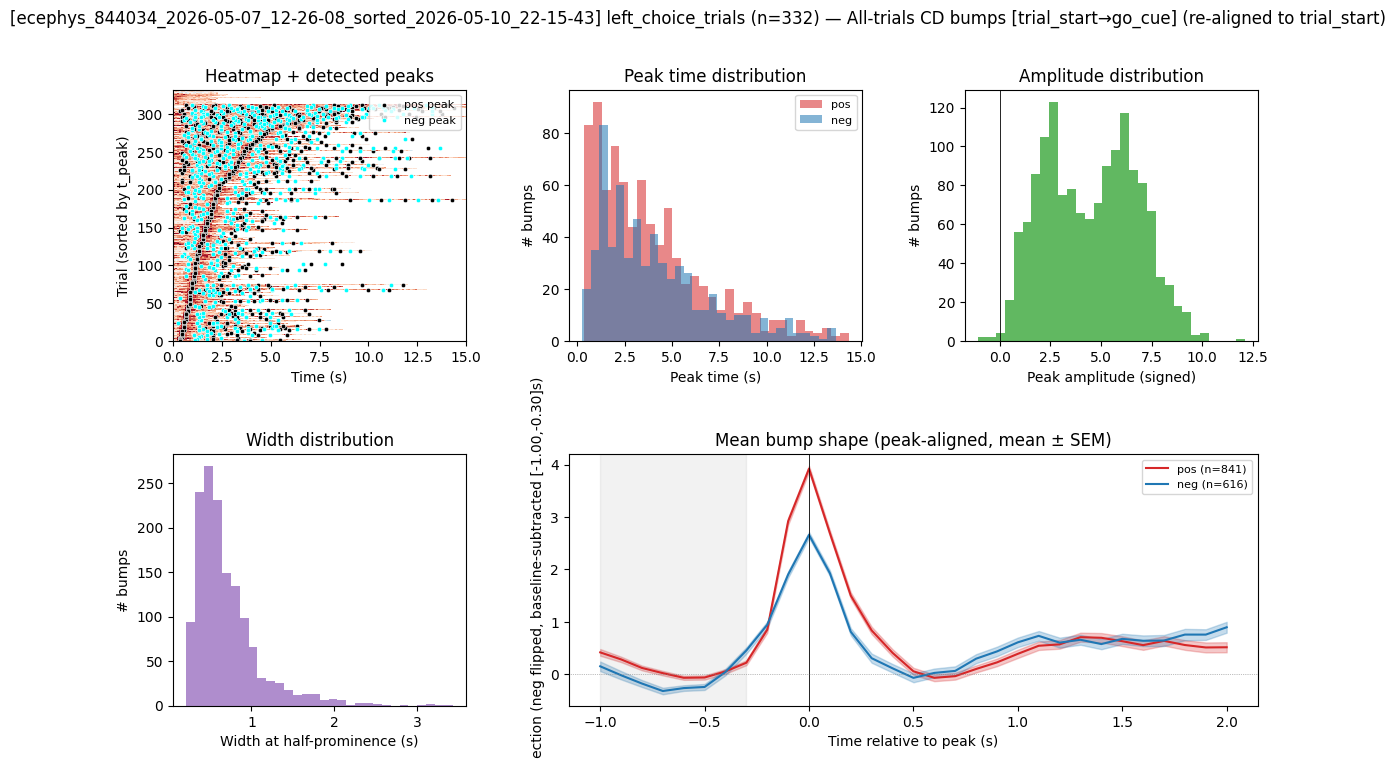

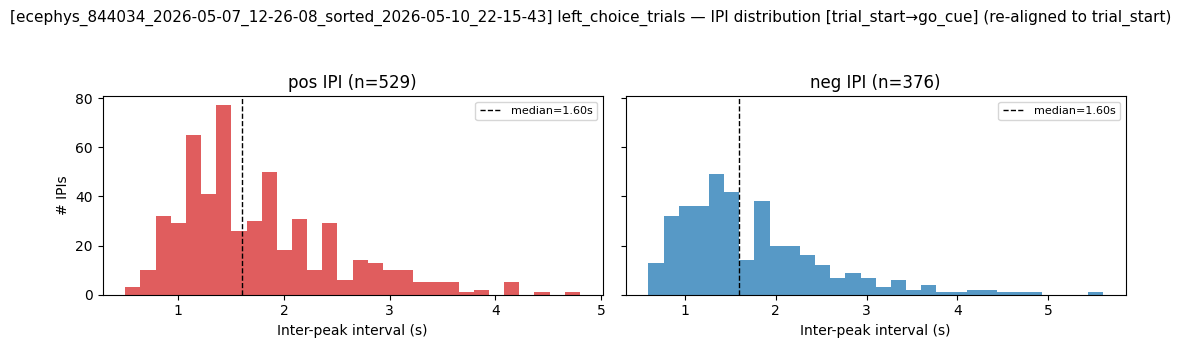

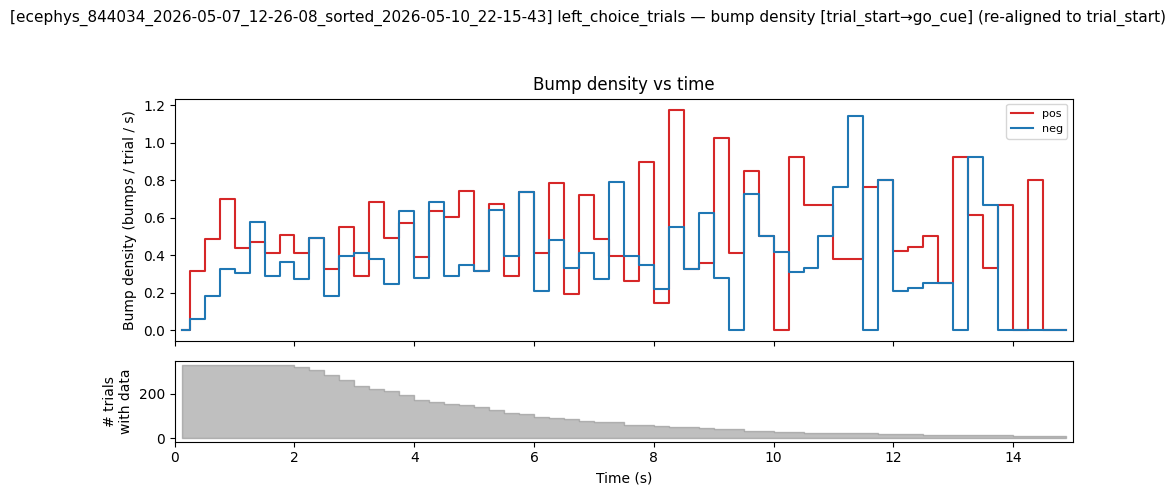


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb

[ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45] right_choice_trials: 235/257 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 532           3.05         3.1        7.202502     1.770809      0.577450   0.423476     2.910208    4.053704
     pos 393           2.85         3.0        3.989853     1.881901      0.636852   0.460959     2.632558   -3.360657


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


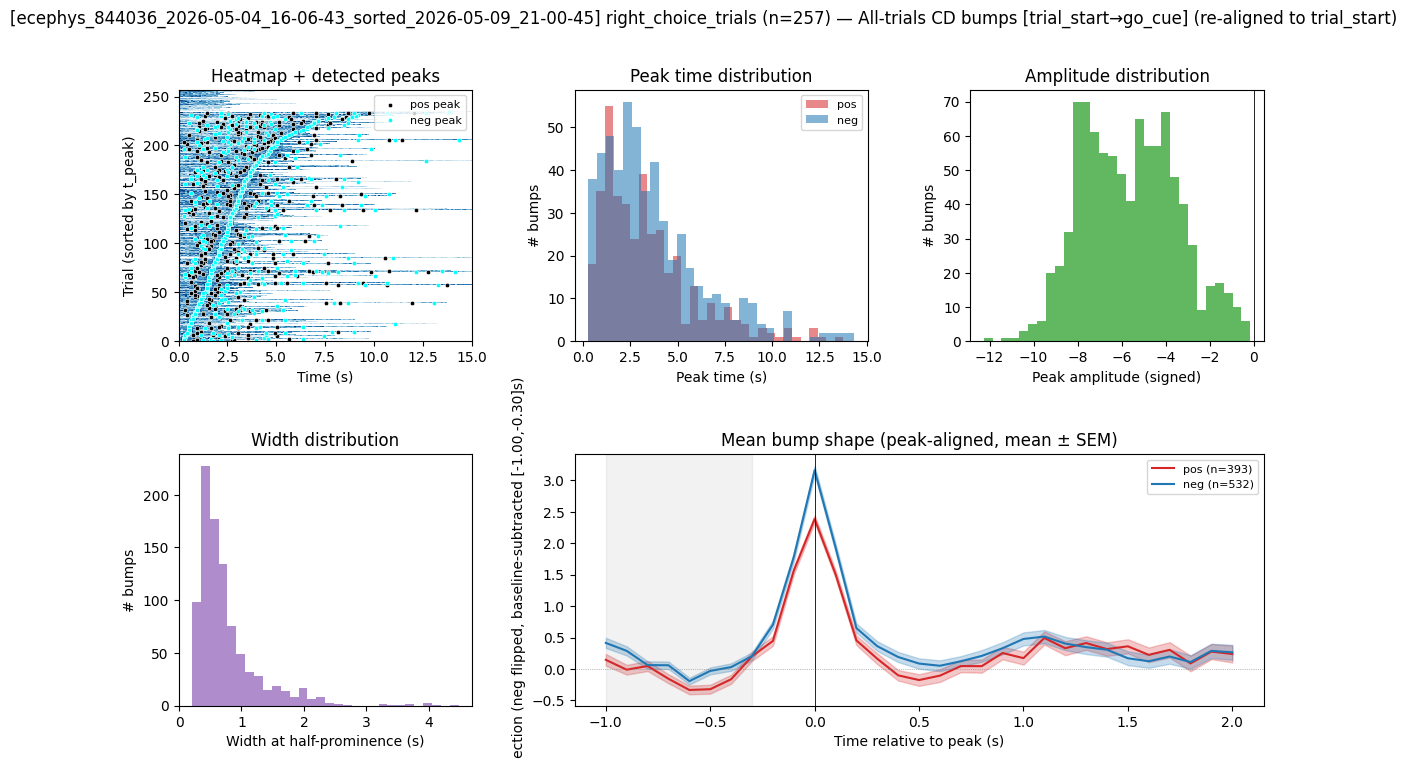

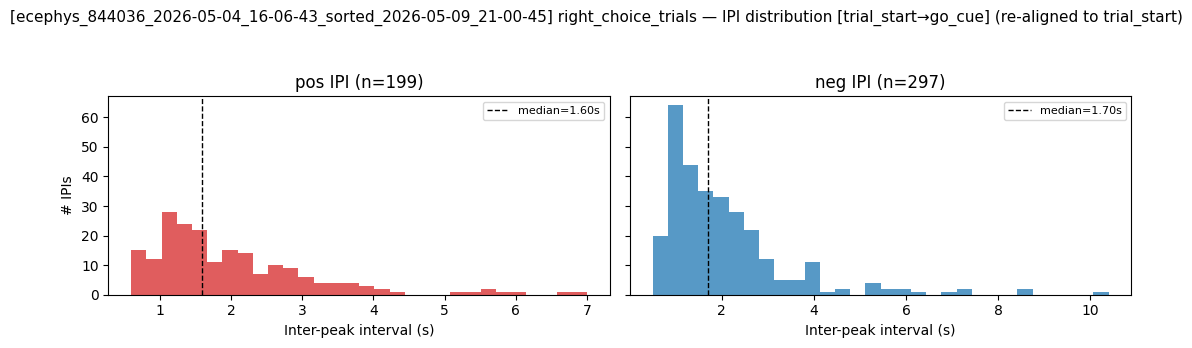

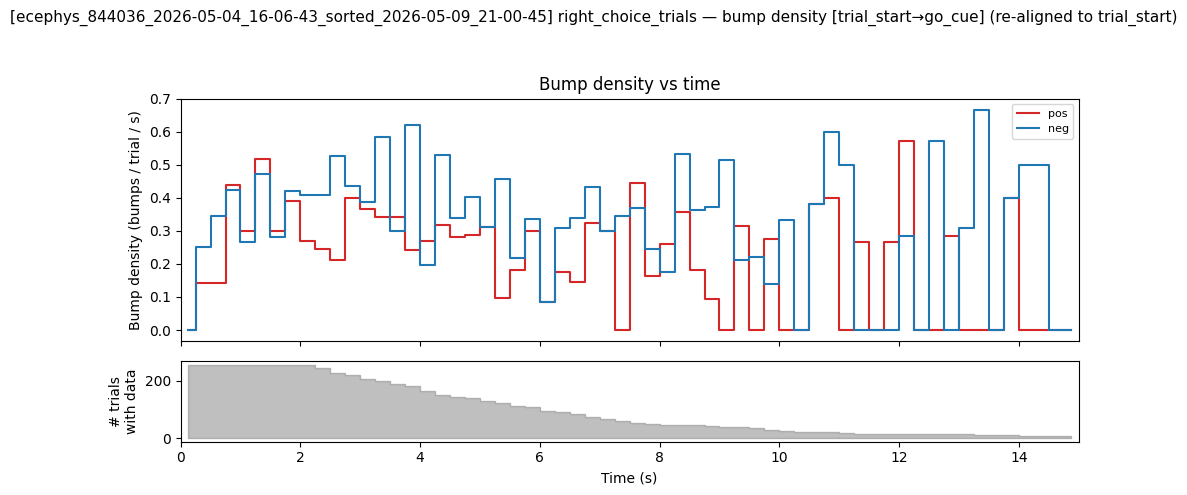


[ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45] left_choice_trials: 214/246 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 419           2.65         2.7        6.897331     2.260104      0.555947   0.516327     2.932488    3.667812
     pos 284           2.30         2.7        3.646586     2.429164      0.635613   0.508368     2.579445   -2.933054


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


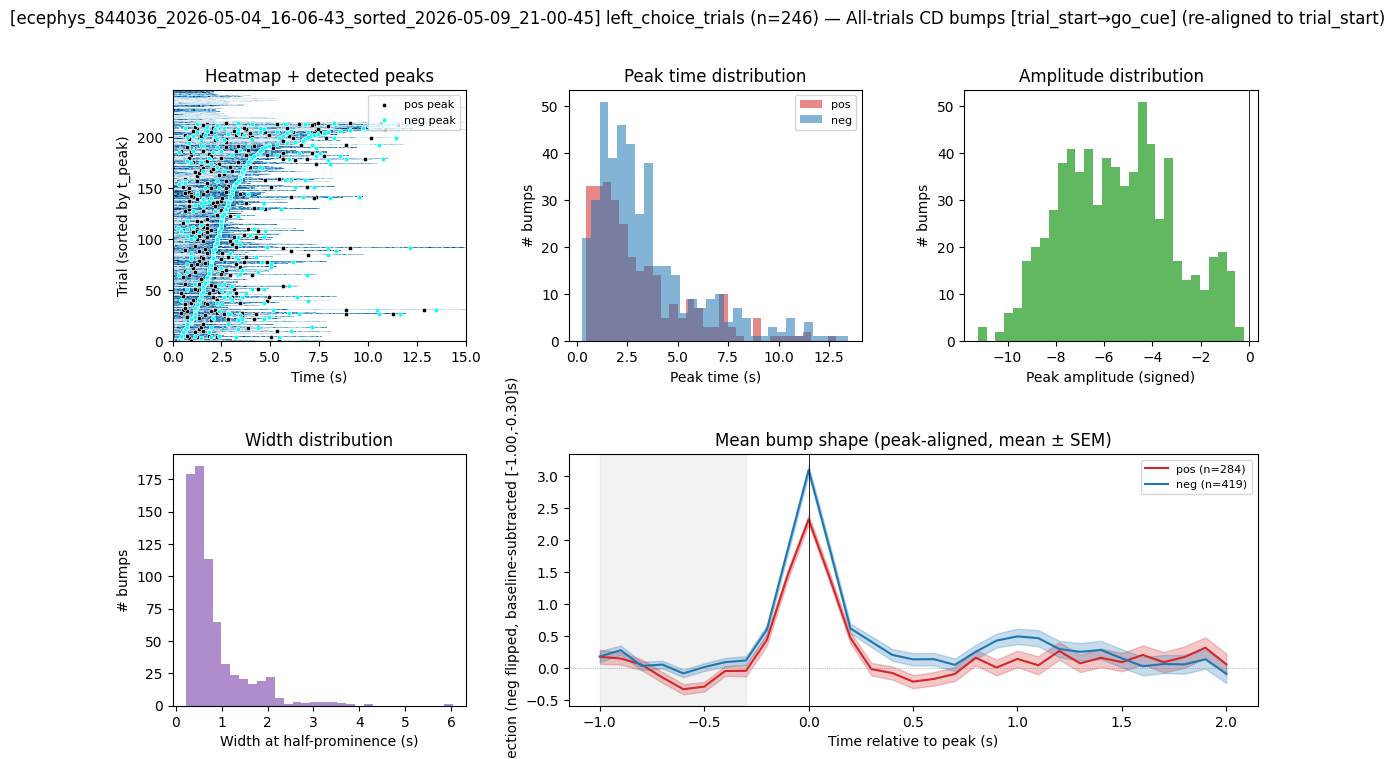

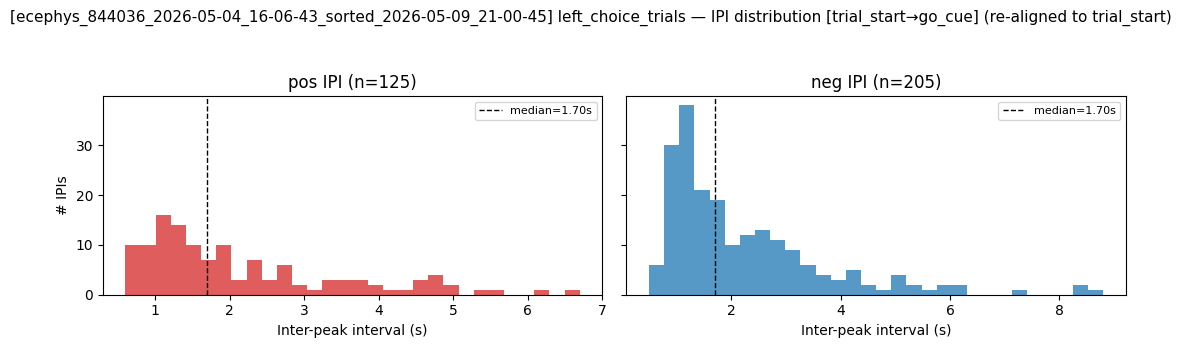

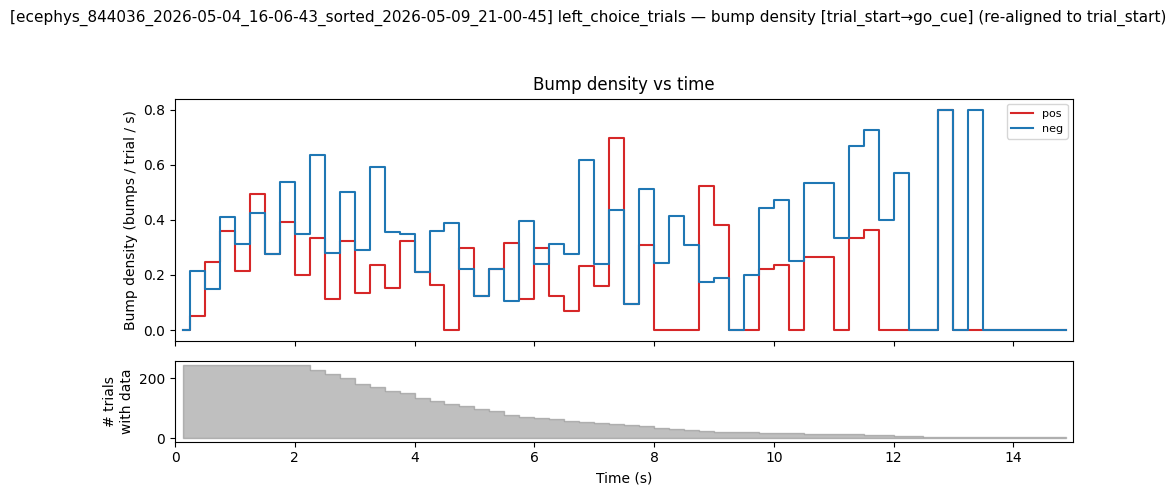


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb

[ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51] right_choice_trials: 212/313 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 350           3.25       3.875        6.456748     1.667101      0.637602   0.541123     2.569239    3.940913
     pos 232           3.15       3.225        3.753155     1.489417      0.650363   0.641680     2.446217   -2.846886


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


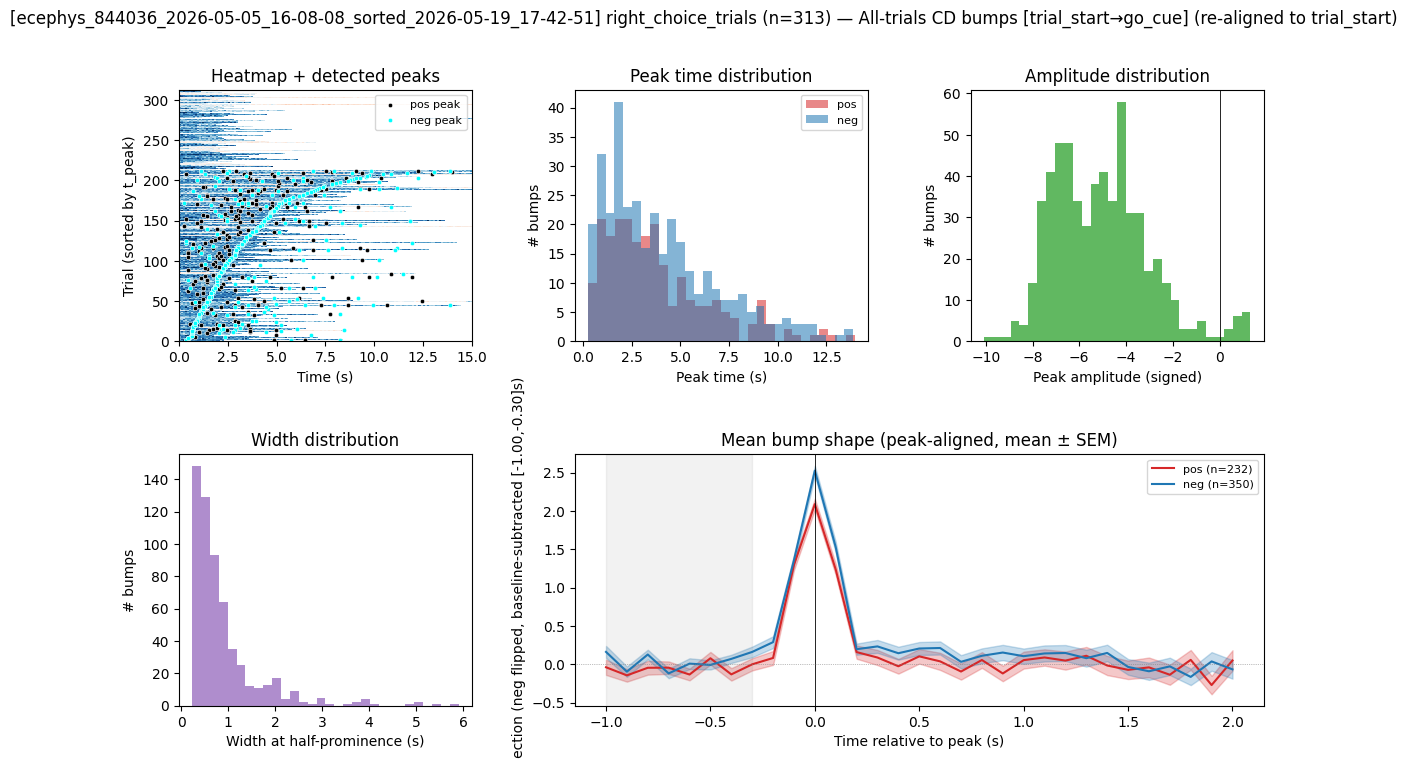

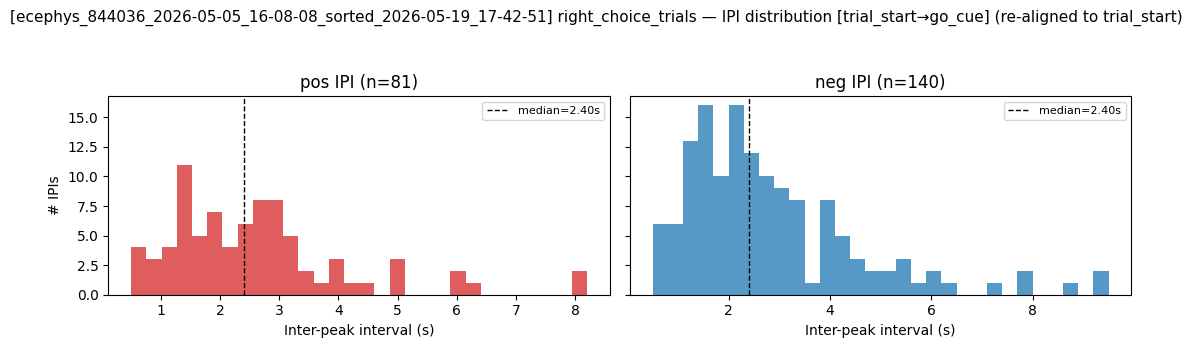

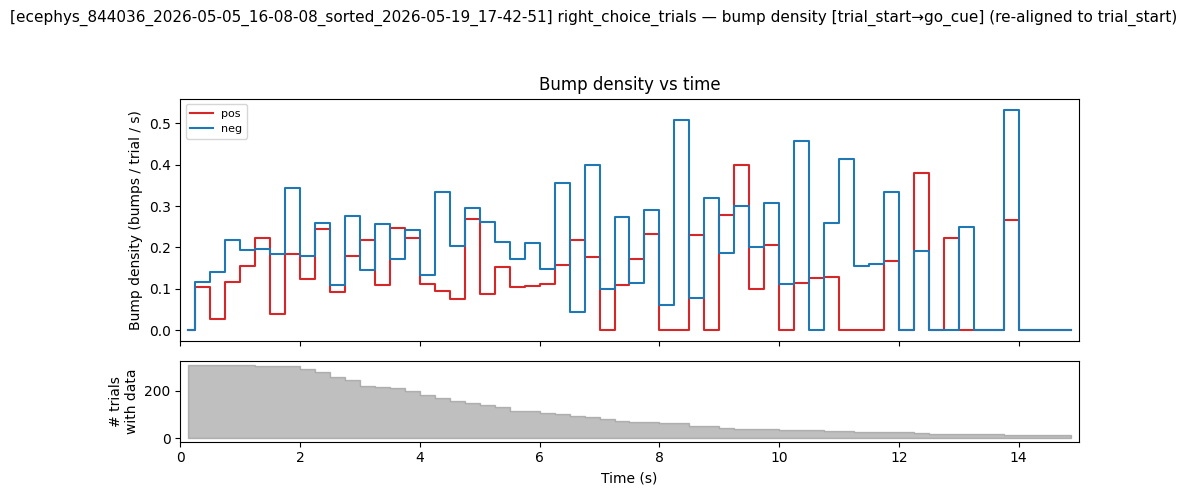


[ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51] left_choice_trials: 111/183 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 168           2.85       3.425        6.868889     1.349056      0.623299   0.549334     2.561935    4.263534
     pos 110           3.15       3.000        4.076275     1.017434      0.633006   0.551522     2.384557   -3.019272


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


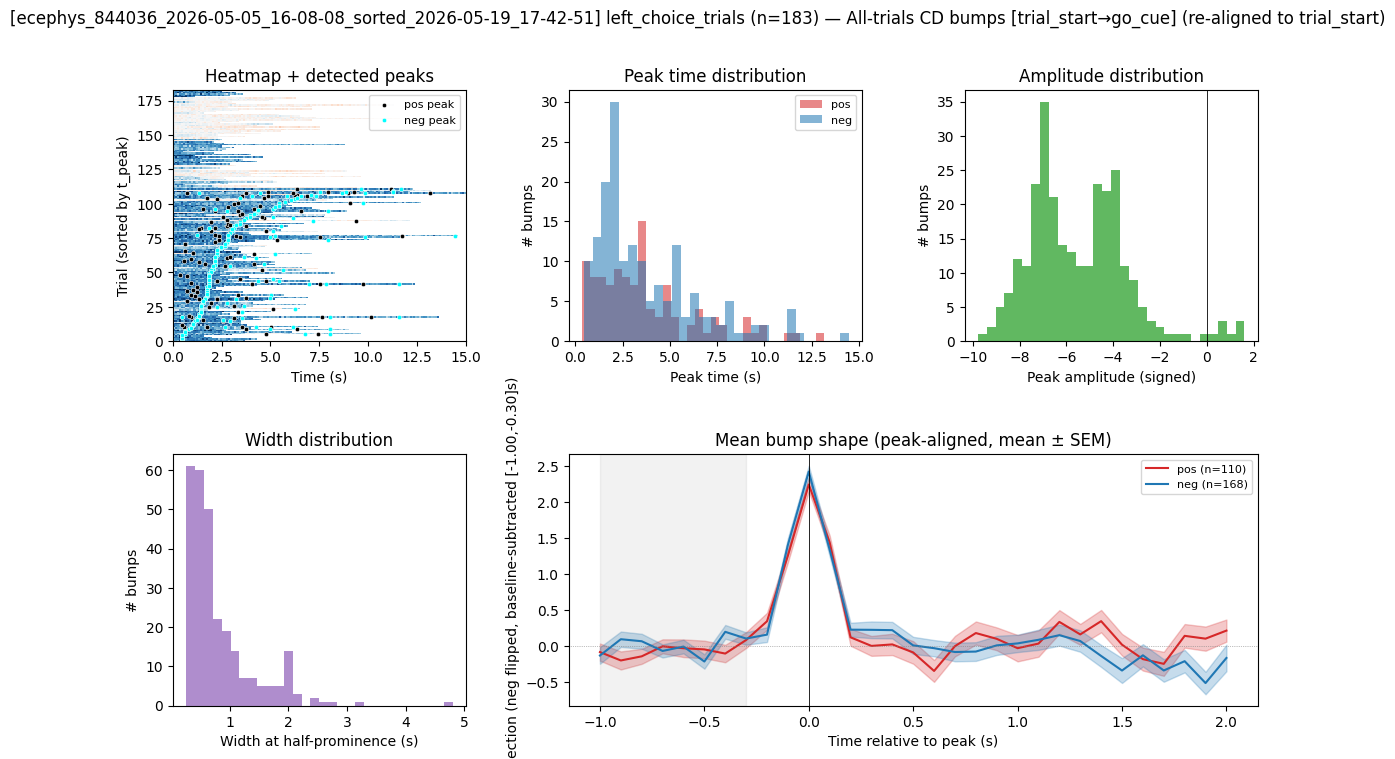

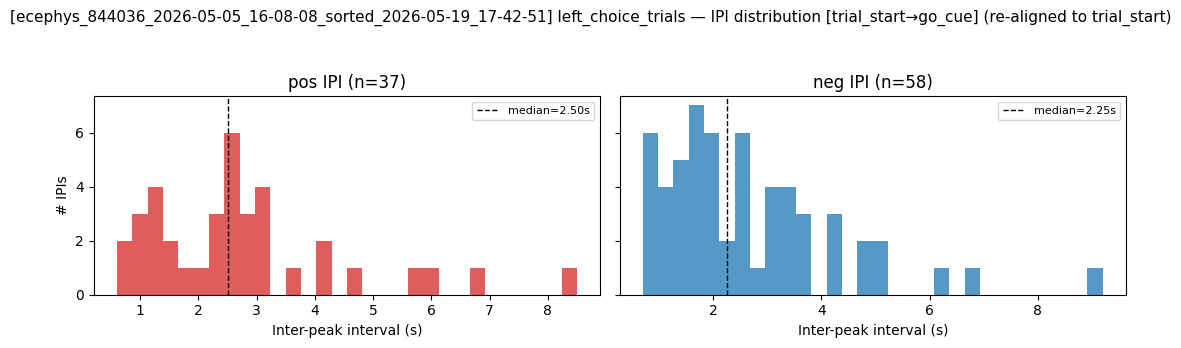

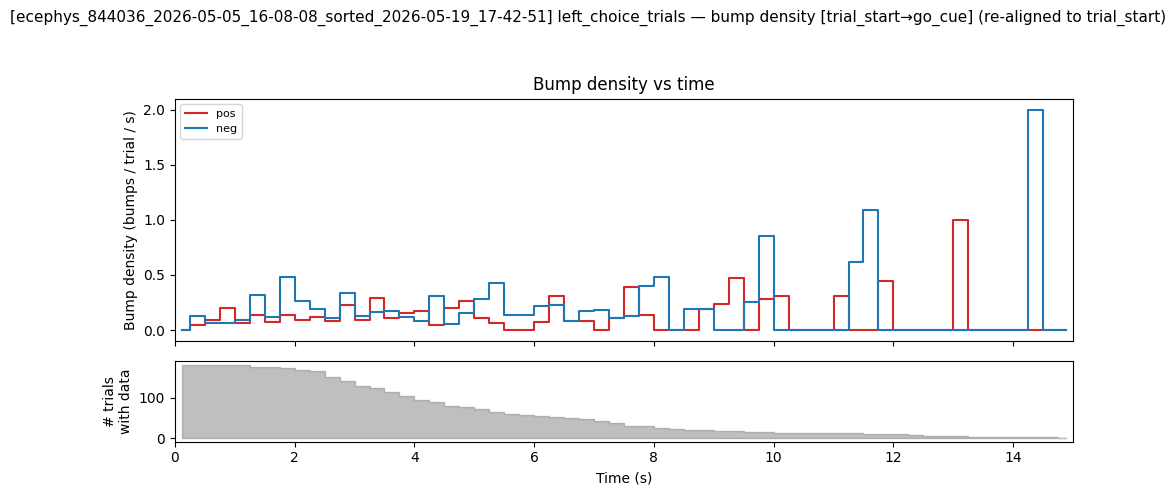


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb

[ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13] right_choice_trials: 249/271 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 503           2.95         3.5        2.654621     0.954469      0.566589   0.471279     2.687976   -2.343735
     pos 653           3.05         3.8        5.860797     1.385426      0.486827   0.324400     2.912180    2.904910


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


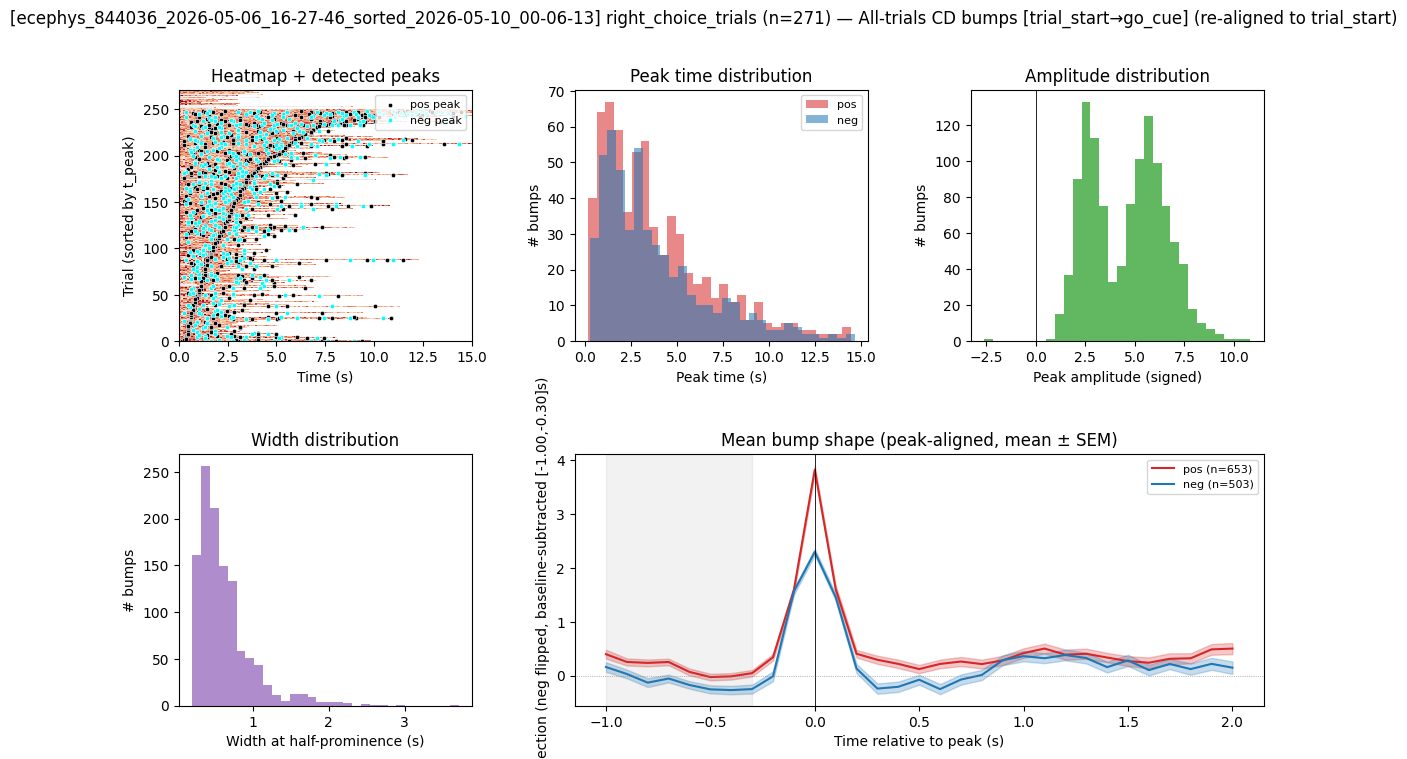

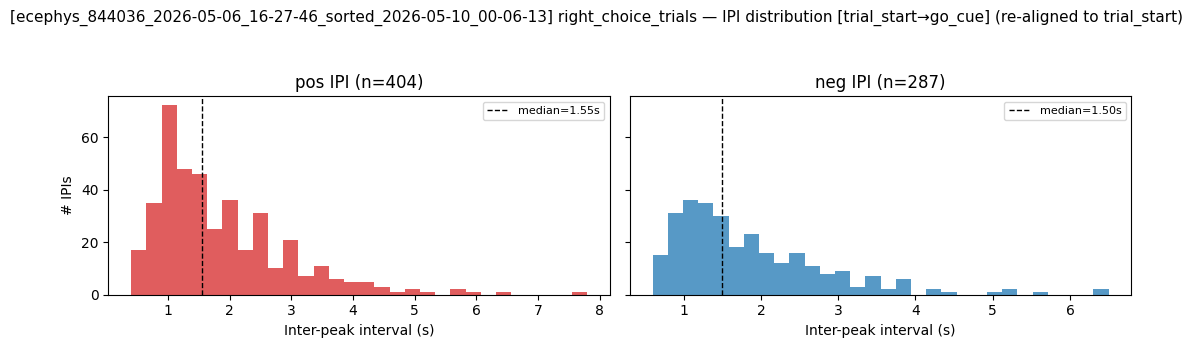

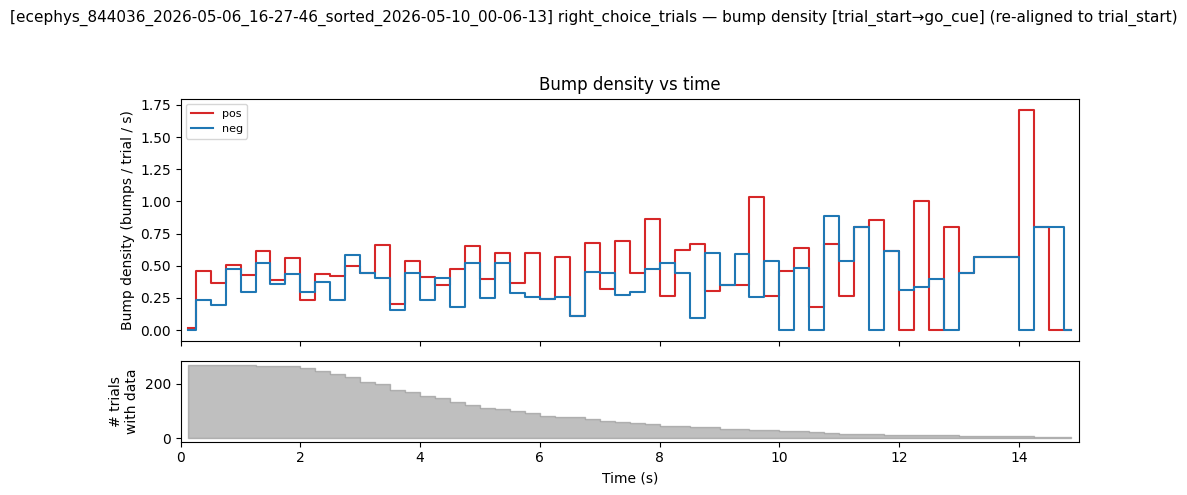


[ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13] left_choice_trials: 170/184 trials with bump in (0, 15) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 293           2.55         3.1        2.682236     1.038405      0.584305   0.507083     2.912229   -2.333942
     pos 387           2.75         3.3        6.096451     1.335912      0.470495   0.334233     3.200890    2.940351


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1))


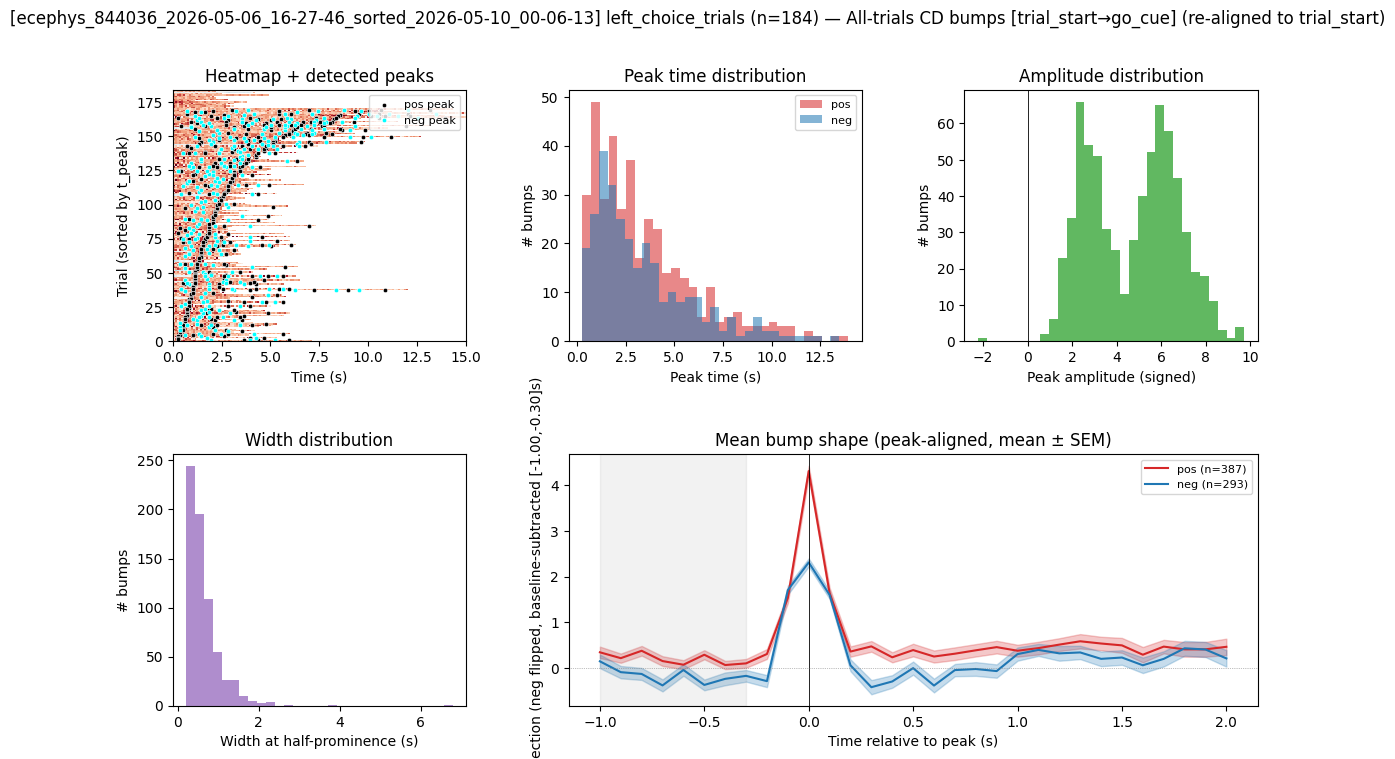

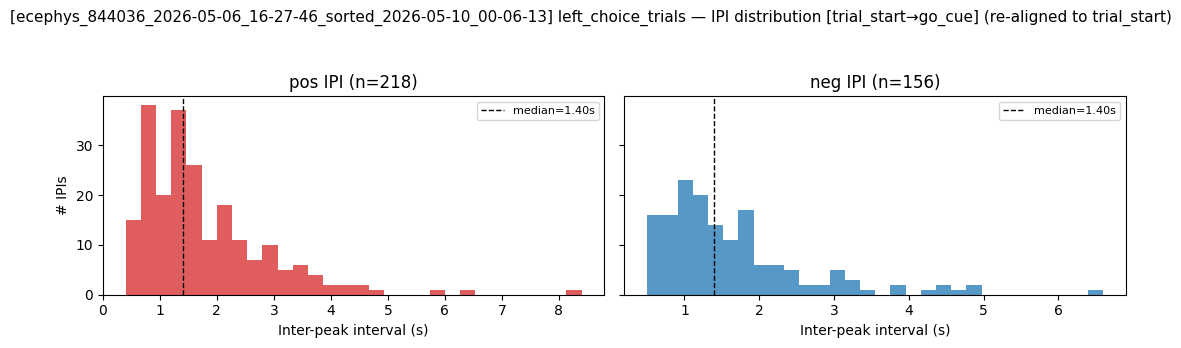

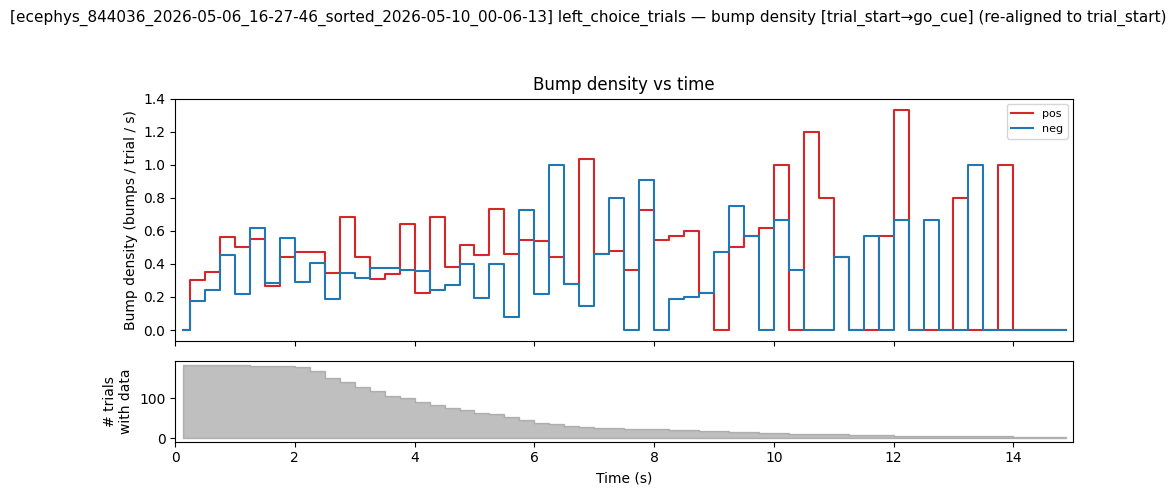

In [8]:
# =============================================================================
# Per-session BUMP DETECTION on single-trial CD projections.
# For each class, detect transient excursions of the projection, summarize
# their timing/amplitude/width statistics, and visualize.
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session_bumps, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

viz_region_group = []
viz_time_window = (-1, 0)
trial_types     = ("switch_LR_trials", "switch_RL_trials")
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

all_bumps = {}  # session -> {class_name: DataFrame}

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        print(f"[skip] missing files for {session}")
        continue

    print(f"\n=== Session: {session} ===")
    sess = load_cd_session(zpath, beh_csv)

    # Detect bumps in 0-3 s after trial_start (re-aligned per trial).
    # Allow multiple bumps per trial — top-K ranked by prominence per polarity.
    dfs = plot_cd_session_bumps(
        sess,
        restrict_events=restrict_events,
        restrict_align="trial_start",
        xlim=(0, 15),
        search_window=(0, 15),
        polarity="both",          # detect positive and negative excursions
        smooth_sigma_sec=0.15,
        min_prominence=2.0,       # tune to your signal scale
        min_width_sec=0.2,
        max_per_trial=500,          # up to 5 bumps per polarity per trial
        shape_window=(-1.0, 2.0),
        return_df=True,
        trial_types=["right_choice_trials", "left_choice_trials"],
    )
    if dfs:
        all_bumps[session] = dfs



In [ ]:
# =============================================================================
# Aggregate CD across the listed sessions and plot averages
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, aggregate_cd_sessions, plot_cd_aggregate,
    region_label,
)

region_lbl, region_print = region_label(viz_region_group)
required_suffix = f"_{region_lbl}_"
print(f"Aggregating region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

sessions_data = []
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue
    sessions_data.append(load_cd_session(zpath, beh_csv))

print(f"\nLoaded {len(sessions_data)} session(s) for aggregation.")
agg = aggregate_cd_sessions(sessions_data)
plot_cd_aggregate(
    agg,
    distribution_window=distribution_window,
    smooth_gauss=0.1,
)
